## StyleSense: Exploratory Data Analysis (EDA)

This notebook explores the patterns, distributions, and relationships in the five
enriched datasets produced by the feature engineering notebook.

**What EDA does:**
EDA is where we stop building and start asking questions. We use charts, summaries,
and cross-dataset comparisons to understand what is actually happening in the business
before drawing any formal conclusions or building dashboards.

**Sections in this notebook:**
1. Sales EDA - revenue trends, quarterly performance, day-of-week patterns, channel comparison, discount impact
2. Customer EDA - demographics, RFM segments, spending behaviour, geography
3. Product EDA - price vs margin, full product margin ranking
4. Expenses EDA - fixed vs variable cost structure, monthly trend
5. Inventory EDA - stock health, stockout risk, at-risk products
6. Cross-dataset relationships - P&L view, RFM segments in sales, seasonal stock alignment

In [1]:
#  Library imports
import pandas as pd               # data loading, grouping, and table operations
import numpy as np                 # numerical calculations
import matplotlib.pyplot as plt    # drawing charts
import matplotlib.ticker as mticker  # formatting axis labels (e.g. adding $ signs)
import seaborn as sns              # statistical charts built on matplotlib

sns.set_theme(style="whitegrid")   # white background with light grid lines
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 10

# Consistent colour palette used across all charts
BLUE   = "#1f77b4"
GREEN  = "#2ca02c"
ORANGE = "#ff7f0e"
RED    = "#d62728"
PURPLE = "#9467bd"
TEAL   = "#17becf"

In [2]:
# Load all five enriched datasets from the feature engineering notebook.
# parse_dates converts date columns from plain text to proper datetime objects,
# which enables date arithmetic and time-based grouping.
sales     = pd.read_csv('sales_featured.csv',     parse_dates=['date'])
customers = pd.read_csv('customers_featured.csv', parse_dates=['first_purchase_date', 'last_purchase_date'])
products  = pd.read_csv('products_featured.csv')
expenses  = pd.read_csv('expenses_featured.csv',  parse_dates=['date'])
inventory = pd.read_csv('inventory_featured.csv', parse_dates=['date'])

# dt.to_period('M') collapses a full date (e.g. 2024-03-15) to just its month (2024-03).
# This lets us group all records from the same calendar month together in one step.
sales['month']     = sales['date'].dt.to_period('M')
expenses['month']  = expenses['date'].dt.to_period('M')
inventory['month'] = inventory['date'].dt.to_period('M')

In [3]:
# Confirm all datasets loaded with the expected columns.
print(f"  sales cols     : {list(sales.columns)}")
print(f"  customer cols  : {list(customers.columns)}")
print(f"  inventory cols : {list(inventory.columns)}")
print(f"  expenses cols  : {list(expenses.columns)}")
print(f"  products cols  : {list(products.columns)}")

  sales cols     : ['sale_id', 'date', 'store_channel', 'payment_method', 'product_id', 'product_name', 'category', 'sub_category', 'quantity_sold', 'unit_price', 'discount_pct', 'discount_amount', 'total_sale', 'cost_total', 'gross_profit', 'customer_id', 'is_promotion', 'is_returned', 'net_profit', 'year', 'quarter', 'month_num', 'month_name', 'day_of_week', 'is_weekend', 'days_since_start', 'profit_margin_pct', 'revenue_per_unit', 'break_even_sale', 'profitability', 'season', 'catalogue_margin_pct', 'is_winter', 'is_summer', 'cost_price', 'margin_erosion', 'month']
  customer cols  : ['customer_id', 'name', 'email', 'age', 'gender', 'city', 'state', 'segment', 'total_items_purchased', 'total_spent', 'num_orders', 'last_purchase_date', 'favourite_category', 'first_purchase_date', 'avg_order_value', 'age_group', 'derived_segment', 'recency_days', 'tenure_days', 'R_score', 'F_score', 'M_score', 'RFM_score', 'RFM_segment']
  inventory cols : ['date', 'product_id', 'product_name', 'categ


## Sales EDA

The sales dataset covers 18 months of transactions (January 2024 – June 2025).
We start with the business headline numbers, then zoom into monthly and quarterly trends,
day-of-week patterns, channel comparison, and how discounts affect volume and margin.

#### Business overview

A summary of the key headline numbers across the full 18-month period.
These are the top-level figures that set the context for all analysis that follows.

In [4]:
# Key business metrics across the full dataset.
# Note: avg profit margin excludes returned transactions (net_profit = 0 for returns)
# to avoid deflating the margin average with zero-profit rows.
print(f"Transactions    : {len(sales):,}")
print(f"Date range      : {sales['date'].min().date()} to {sales['date'].max().date()}")
print(f"Total revenue   : ${sales['total_sale'].sum():,.2f}")
print(f"Total net profit: ${sales['net_profit'].sum():,.2f}")
print(f"Avg order value : ${sales['total_sale'].mean():.2f}")
print(f"Avg profit margin: {sales[sales['net_profit']>0]['profit_margin_pct'].mean():.1f}%")
print(f"Return rate     : {sales['is_returned'].mean()*100:.1f}%")
print(f"Promotion rate  : {sales['is_promotion'].mean()*100:.1f}%")

Transactions    : 9,989
Date range      : 2024-01-01 to 2025-06-30
Total revenue   : $672,108.94
Total net profit: $402,839.75
Avg order value : $67.28
Avg profit margin: 64.5%
Return rate     : 4.8%
Promotion rate  : 26.9%


#### 1. Monthly Revenue & Profit Trend

Three panels stacked: monthly revenue, monthly net profit, and transaction count.
Reading all three together reveals whether growth is coming from more customers,
higher spending, or simply more active months and whether profit is keeping pace.

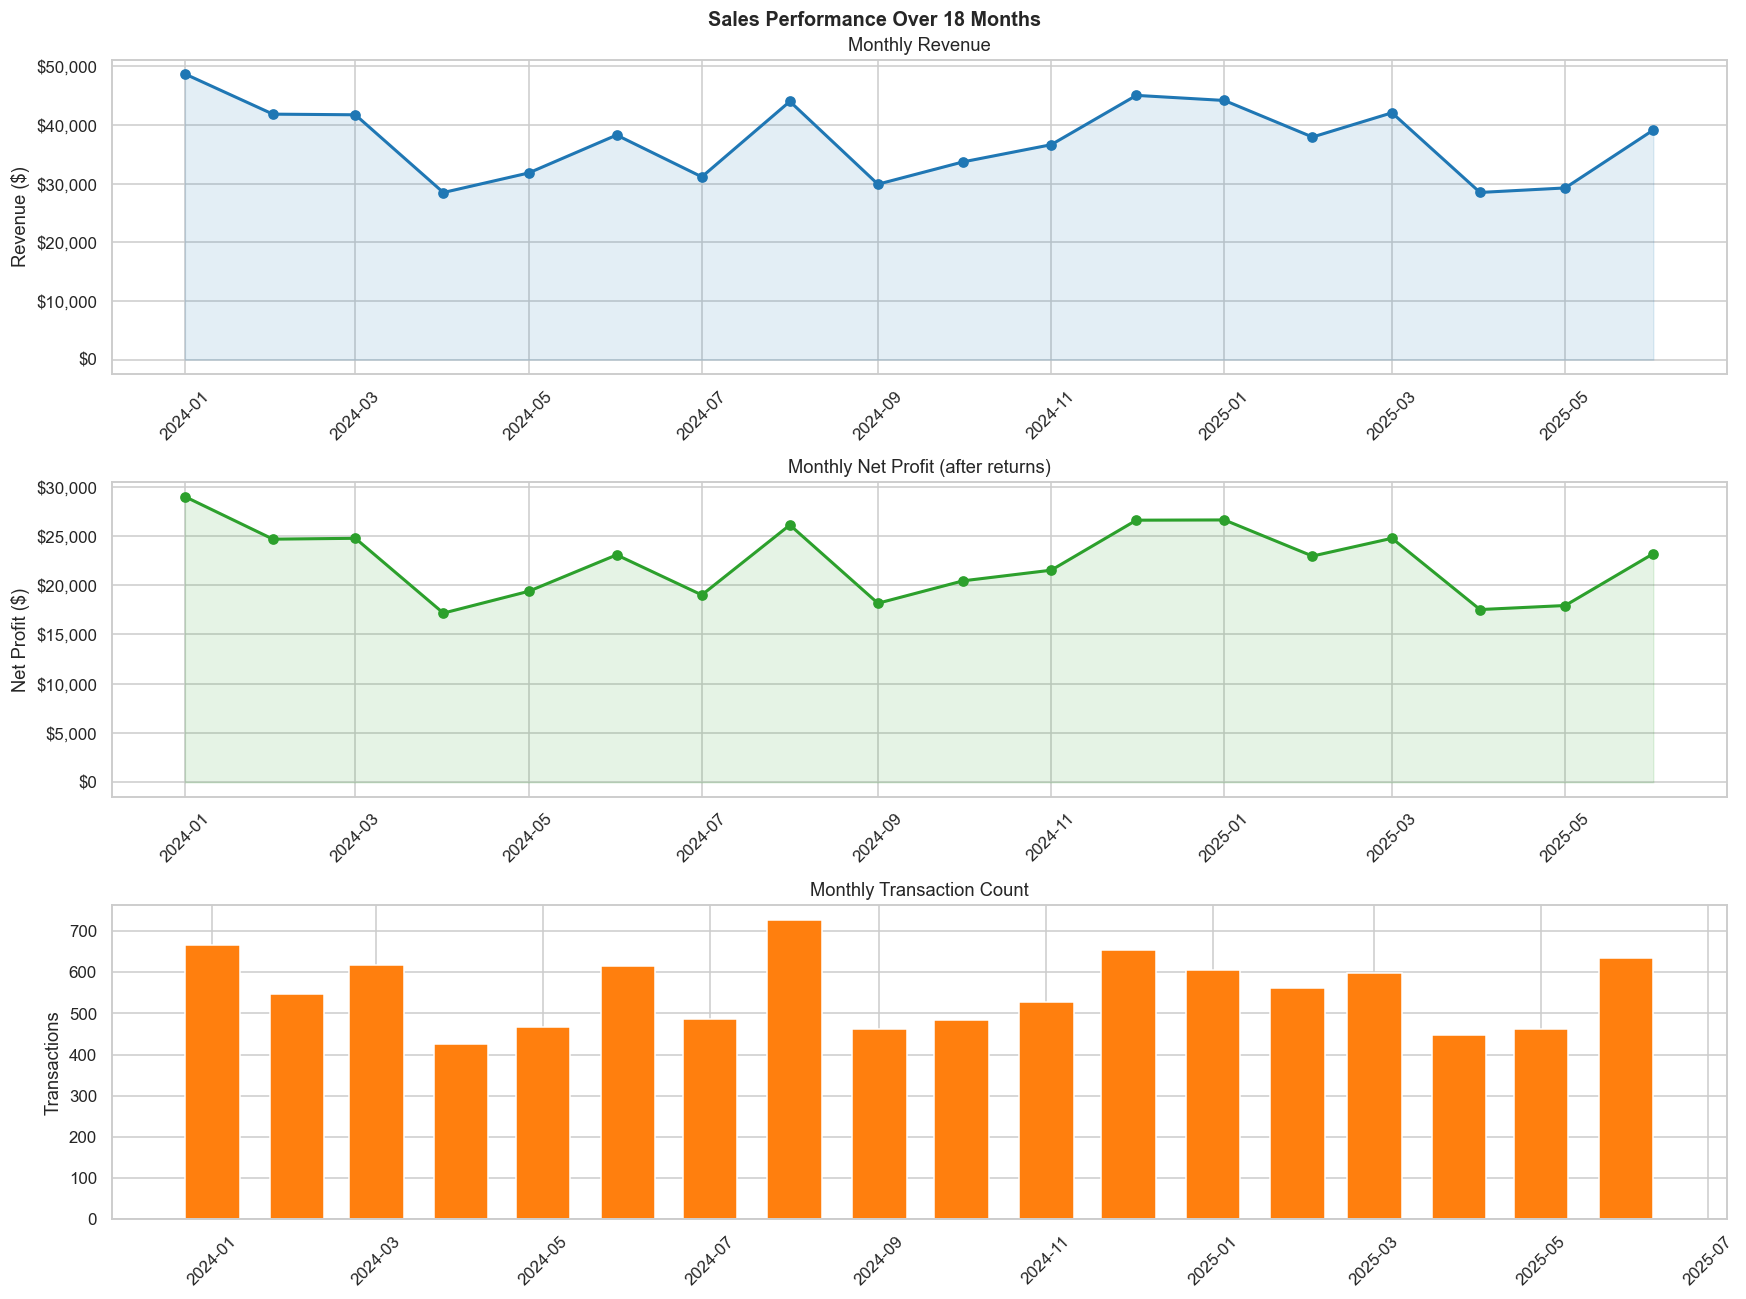

In [5]:
# Aggregate sales by calendar month across four metrics
monthly = sales.groupby('month').agg(
    transactions  = ('sale_id', 'count'),
    revenue       = ('total_sale', 'sum'),
    net_profit    = ('net_profit', 'sum'),
    avg_margin    = ('profit_margin_pct', 'mean')
).reset_index()
# Convert period to timestamp so matplotlib can plot it on a proper time axis
monthly['month_dt'] = monthly['month'].dt.to_timestamp()

fig, axes = plt.subplots(3, 1, figsize=(16, 12))

# Panel 1: Monthly revenue — line with shaded fill underneath
axes[0].plot(monthly['month_dt'], monthly['revenue'], color=BLUE, marker='o', linewidth=2)
axes[0].fill_between(monthly['month_dt'], monthly['revenue'], alpha=0.12, color=BLUE)
axes[0].set_title("Monthly Revenue")
axes[0].set_ylabel("Revenue ($)")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
axes[0].tick_params(axis='x', rotation=45)

# Panel 2: Net profit — should track revenue proportionally;
# if the two lines diverge, something is compressing margin that month
axes[1].plot(monthly['month_dt'], monthly['net_profit'], color=GREEN, marker='o', linewidth=2)
axes[1].fill_between(monthly['month_dt'], monthly['net_profit'], alpha=0.12, color=GREEN)
axes[1].set_title("Monthly Net Profit (after returns)")
axes[1].set_ylabel("Net Profit ($)")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
axes[1].tick_params(axis='x', rotation=45)

# Panel 3: Transaction count — separates volume effect from value effect
axes[2].bar(monthly['month_dt'], monthly['transactions'], color=ORANGE, width=20)
axes[2].set_title("Monthly Transaction Count")
axes[2].set_ylabel("Transactions")
axes[2].tick_params(axis='x', rotation=45)

plt.suptitle("Sales Performance Over 18 Months", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**What the charts show**:

Revenue and net profit move together across the **18 months**. The distance between the two lines stays almost the same. There is no month where revenue increases a lot but profit drops sharply. This suggests that profit margins stay fairly stable each month.

The highest revenue month is **January 2024** at about **49k**. Other strong months appear around **August 2024** and **November** to **December 2024**. The lowest months are **April 2024** and **March to April 2025**, where revenue drops to around **29k**.

The number of transactions shows a similar pattern. **August 2024** has the highest number of transactions at about **715**, while **April 2024** has the lowest at about **430**. This pattern suggests the business follows a seasonal trend rather than random changes.

#### 2. Quarterly Performance

Quarterly grouping smooths monthly noise and makes year-on-year comparison easier.
The two panels show total revenue per quarter and average profit margin per quarter.

Quarterly Performance Summary:
  label  transactions   revenue  net_profit  avg_margin  return_rate
2024 Q1          1831 132219.67    78410.21        61.0          4.6
2024 Q2          1506  98533.19    59612.77        61.7          4.8
2024 Q3          1676 105023.95    63279.49        61.3          5.2
2024 Q4          1666 115339.22    68553.67        61.6          4.4
2025 Q1          1764 124138.60    74329.02        61.0          4.9
2025 Q2          1546  96854.31    58654.59        61.7          5.1


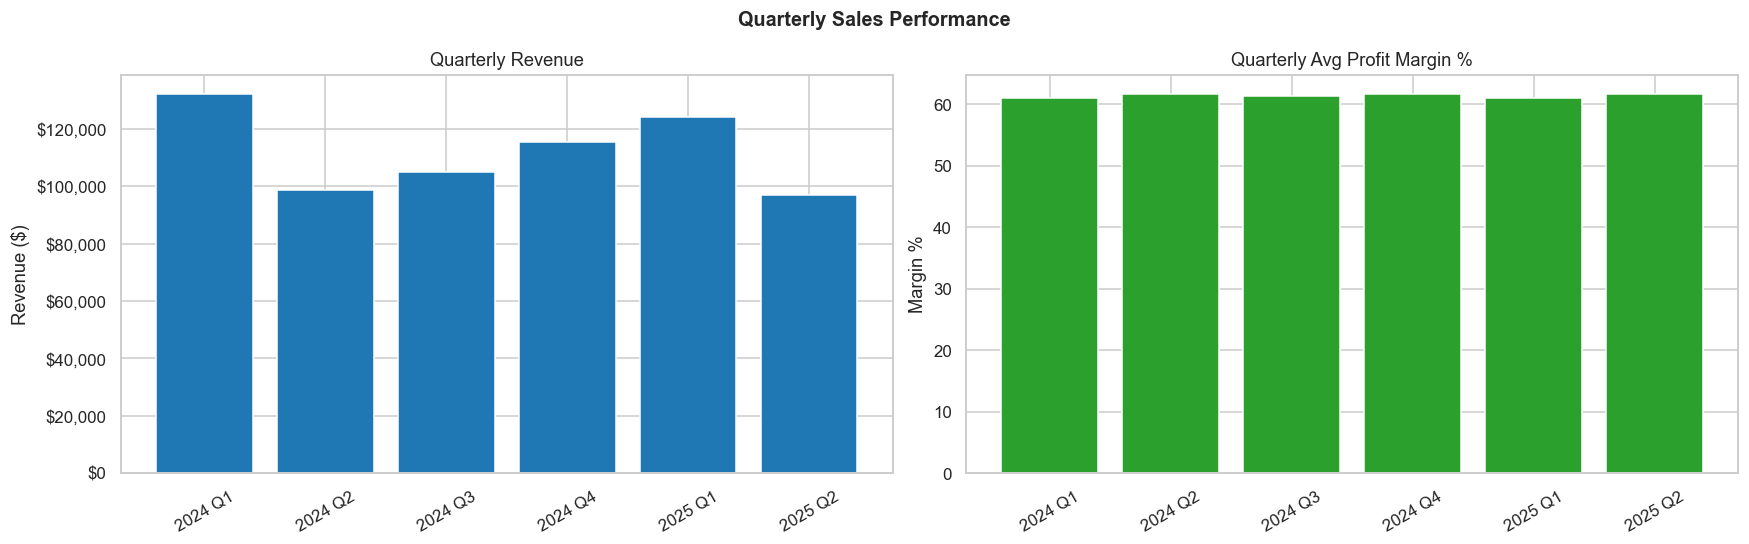

In [6]:
quarterly = sales.groupby(['year', 'quarter']).agg(
    transactions  = ('sale_id', 'count'),
    revenue       = ('total_sale', 'sum'),
    net_profit    = ('net_profit', 'sum'),
    avg_margin    = ('profit_margin_pct', 'mean'),
    return_rate   = ('is_returned', 'mean')
).reset_index()
quarterly['return_rate'] = (quarterly['return_rate'] * 100).round(1)
quarterly['avg_margin']  = quarterly['avg_margin'].round(1)
quarterly['label'] = quarterly['year'].astype(str) + ' Q' + quarterly['quarter'].astype(str)

print("Quarterly Performance Summary:")
print(quarterly[['label', 'transactions', 'revenue', 'net_profit', 'avg_margin', 'return_rate']].to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: quarterly revenue bars
axes[0].bar(quarterly['label'], quarterly['revenue'], color=BLUE)
axes[0].set_title("Quarterly Revenue")
axes[0].set_ylabel("Revenue ($)")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
axes[0].tick_params(axis='x', rotation=30)

# Right: quarterly avg profit margin — tells us if margin quality changes by quarter
axes[1].bar(quarterly['label'], quarterly['avg_margin'], color=GREEN)
axes[1].set_title("Quarterly Avg Profit Margin %")
axes[1].set_ylabel("Margin %")
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle("Quarterly Sales Performance", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**What the charts show:**

- **2024 Q1** is the strongest quarter with revenue of **130k**, mainly driven by the high sales in **January**. Revenue then drops to its lowest point in **2024 Q2** at **99k** before improving again through **Q3 and Q4**.

- **2025 Q1** shows a strong recovery with revenue reaching **125k**. However, **2025 Q2** is the weakest quarter overall at **97k**, noting that this period only includes **April to June 2025**.

An important observation comes from the margin chart. All six quarters have almost identical profit margins of about **61 to 62** percent. The margin trend is very stable.

This means that even though revenue changes from quarter to quarter, the business consistently earns about the same proportion of profit from each dollar of sales. Discounts and seasonal changes are not significantly reducing profit margins at the quarterly level.

#### 3. Day-of-Week & Weekend Patterns

Does the day of the week meaningfully affect how many transactions happen or
how much customers spend per order?

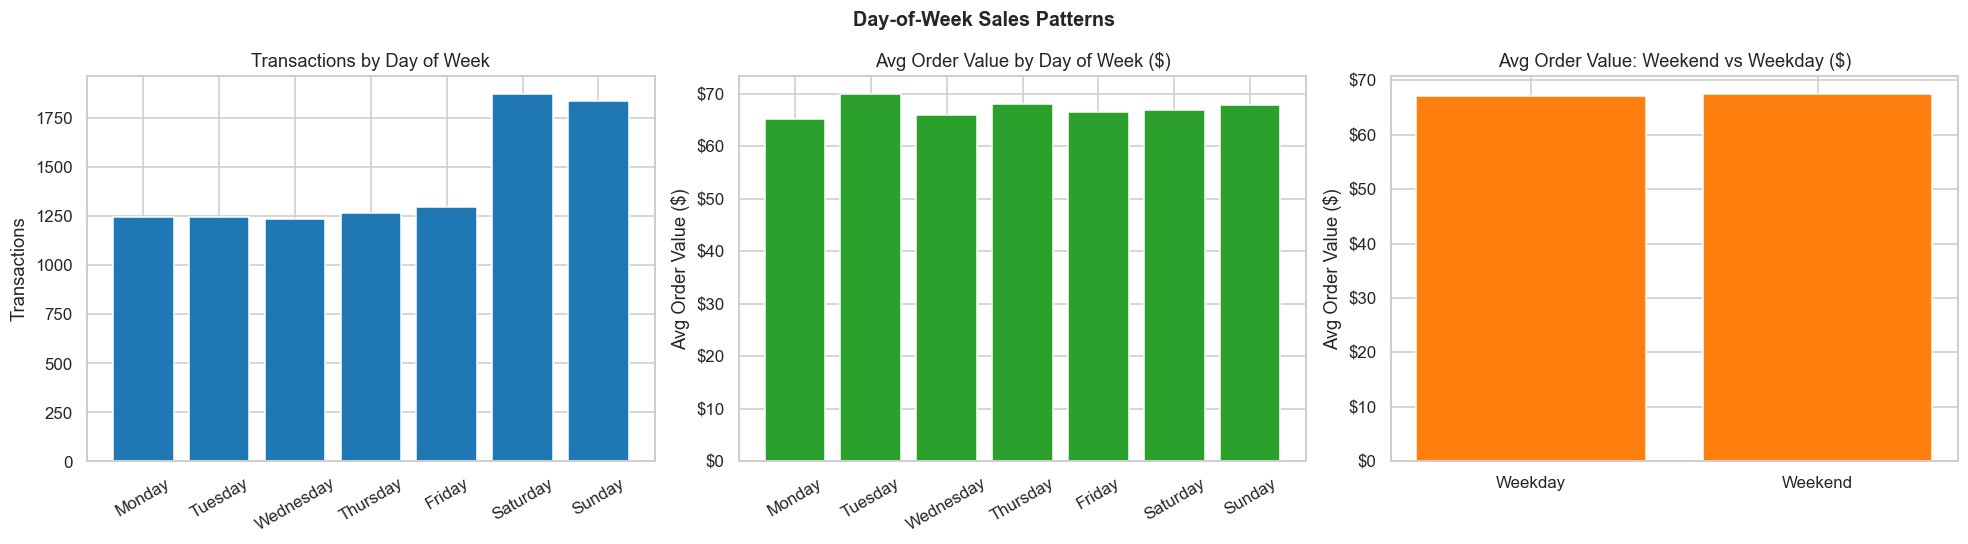

In [7]:
# Group by day of week; reindex forces Mon–Sun order (not alphabetical)
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow = sales.groupby('day_of_week').agg(
    transactions    = ('sale_id', 'count'),
    avg_order_value = ('total_sale', 'mean'),
    avg_margin      = ('profit_margin_pct', 'mean')
).reindex(dow_order).reset_index()

weekend_vs_week = sales.groupby('is_weekend').agg(
    transactions    = ('sale_id', 'count'),
    avg_order_value = ('total_sale', 'mean'),
    total_revenue   = ('total_sale', 'sum')
).reset_index()
weekend_vs_week['label'] = weekend_vs_week['is_weekend'].map({True: 'Weekend', False: 'Weekday'})

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Chart 1: transaction count by day
axes[0].bar(dow['day_of_week'], dow['transactions'], color=BLUE)
axes[0].set_title("Transactions by Day of Week")
axes[0].set_ylabel("Transactions")
axes[0].tick_params(axis='x', rotation=30)

# Chart 2: average order value by day
axes[1].bar(dow['day_of_week'], dow['avg_order_value'], color=GREEN)
axes[1].set_title("Avg Order Value by Day of Week ($)")
axes[1].set_ylabel("Avg Order Value ($)")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.0f}"))
axes[1].tick_params(axis='x', rotation=30)

# Chart 3: weekday vs weekend avg order value
axes[2].bar(weekend_vs_week['label'], weekend_vs_week['avg_order_value'], color=ORANGE)
axes[2].set_title("Avg Order Value: Weekend vs Weekday ($)")
axes[2].set_ylabel("Avg Order Value ($)")
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.0f}"))

plt.suptitle("Day-of-Week Sales Patterns", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [8]:
print(dow[['day_of_week', 'transactions', 'avg_order_value', 'avg_margin']].to_string(index=False))

day_of_week  transactions  avg_order_value  avg_margin
     Monday          1244        65.191608   61.306929
    Tuesday          1244        69.978103   61.537484
  Wednesday          1236        66.005882   61.383706
   Thursday          1266        68.062536   60.971074
     Friday          1295        66.593730   60.693073
   Saturday          1871        67.012229   61.767424
     Sunday          1833        67.969787   61.511457


**What the charts show:**

**Weekends (Saturday and Sunday) are clearly the busiest transaction days**, each generating
around 1,820–1,850 transactions compared to ~1,240–1,290 on each weekday. Weekdays are
nearly identical to each other, there is no standout weekday.

However, **average order value is almost identical across all seven days**, hovering between
$65–$70 with minimal variation. The weekday vs weekend comparison confirms that both bars
sit at essentially the same height (~$67–$68).

**The key takeaway:** weekends drive more *volume* but customers do not spend more *per order*
on weekends than on weekdays. If StyleSense wants to increase revenue on weekends, it needs
to maintain the volume advantage and not rely on bigger baskets.

#### 4. Channel Performance

StyleSense sells through two channels: physical store and online.
This section compares transaction share, revenue share, average order value,
return rate, and margin across the two.

Channel Performance Summary:
store_channel  transactions  total_revenue  total_net_profit  avg_order_value  avg_margin  return_rate
       Online          4547      310378.98         185226.35        68.260167        61.1          5.2
     Physical          5442      361729.96         217613.40        66.470040        61.6          4.5


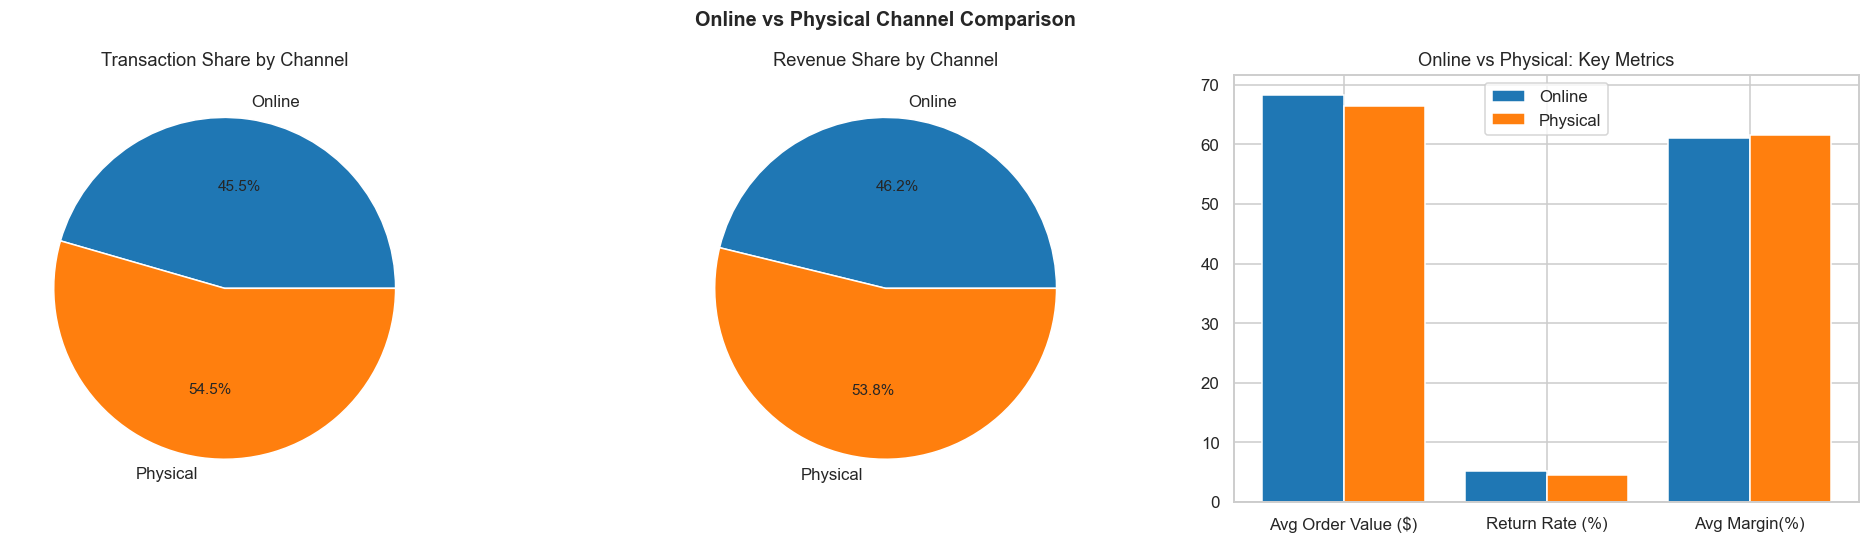

In [9]:
channel = sales.groupby('store_channel').agg(
    transactions     = ('sale_id', 'count'),
    total_revenue    = ('total_sale', 'sum'),
    total_net_profit = ('net_profit', 'sum'),
    avg_order_value  = ('total_sale', 'mean'),
    avg_margin       = ('profit_margin_pct', 'mean'),
    return_rate      = ('is_returned', 'mean')
).reset_index()
channel['return_rate'] = (channel['return_rate'] * 100).round(1)
channel['avg_margin']  = channel['avg_margin'].round(1)

print("Channel Performance Summary:")
print(channel.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Pie 1: share of transactions by channel
axes[0].pie(channel['transactions'], labels=channel['store_channel'],
            autopct='%1.1f%%', colors=[BLUE, ORANGE])
axes[0].set_title("Transaction Share by Channel")

# Pie 2: share of revenue by channel
# If this differs from transaction share, one channel has higher average orders
axes[1].pie(channel['total_revenue'], labels=channel['store_channel'],
            autopct='%1.1f%%', colors=[BLUE, ORANGE])
axes[1].set_title("Revenue Share by Channel")

# Bar chart: key metrics side by side — avg order value, return rate, avg margin
x = ['Avg Order Value ($)', 'Return Rate (%)', 'Avg Margin(%)']
online_vals   = [channel[channel['store_channel']=='Online']['avg_order_value'].values[0],
                 channel[channel['store_channel']=='Online']['return_rate'].values[0],
                 channel[channel['store_channel']=='Online']['avg_margin'].values[0]]
physical_vals = [channel[channel['store_channel']=='Physical']['avg_order_value'].values[0],
                 channel[channel['store_channel']=='Physical']['return_rate'].values[0],
                 channel[channel['store_channel']=='Physical']['avg_margin'].values[0]]
x_pos = range(len(x))
axes[2].bar([p - 0.2 for p in x_pos], online_vals,   width=0.4, color=BLUE,   label='Online')
axes[2].bar([p + 0.2 for p in x_pos], physical_vals, width=0.4, color=ORANGE, label='Physical')
axes[2].set_xticks(list(x_pos))
axes[2].set_xticklabels(x)
axes[2].set_title("Online vs Physical: Key Metrics")
axes[2].legend()

plt.suptitle("Online vs Physical Channel Comparison", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**What the charts show:**

The two channels are remarkably balanced. **Physical stores lead slightly on both
transaction share (54.5%) and revenue share (53.8%)**, but the split is close to even.

Looking at the key metrics bar chart, all three indicators; average order value,
return rate, and profit margin are **nearly identical between channels**.
Online has a marginally higher return rate (~5.4% vs ~4.3%), which is expected
since customers cannot try items before buying, but the difference is small.
Margins are essentially the same for both.

**The takeaway:** neither channel is dramatically outperforming the other.
Both are healthy and both earn the same margin quality. Investment decisions
between the two channels should be based on growth potential and cost to serve,
not on a quality gap because there isn't one.

#### 5. Discount Analysis: Volume, Margin & Erosion

StyleSense uses five discount tiers: 0%, 5%, 10%, 15%, 20%.
The key question is whether higher discounts attract enough extra volume
to justify the margin they cost.

Discount Tier Analysis:
 discount_pct  transactions  avg_units_sold  avg_net_profit  avg_margin  avg_erosion  return_rate
            0          4489        1.811985       42.310033   63.104798     3.373927          5.1
            5          2189        1.870260       40.483207   61.860251     4.732668          4.6
           10          1829        1.926189       39.470148   59.843603     6.606862          4.6
           15          1127        1.924579       35.218234   57.581526     8.961863          5.1
           20           355        2.123944       34.958930   55.648197    10.869831          4.2


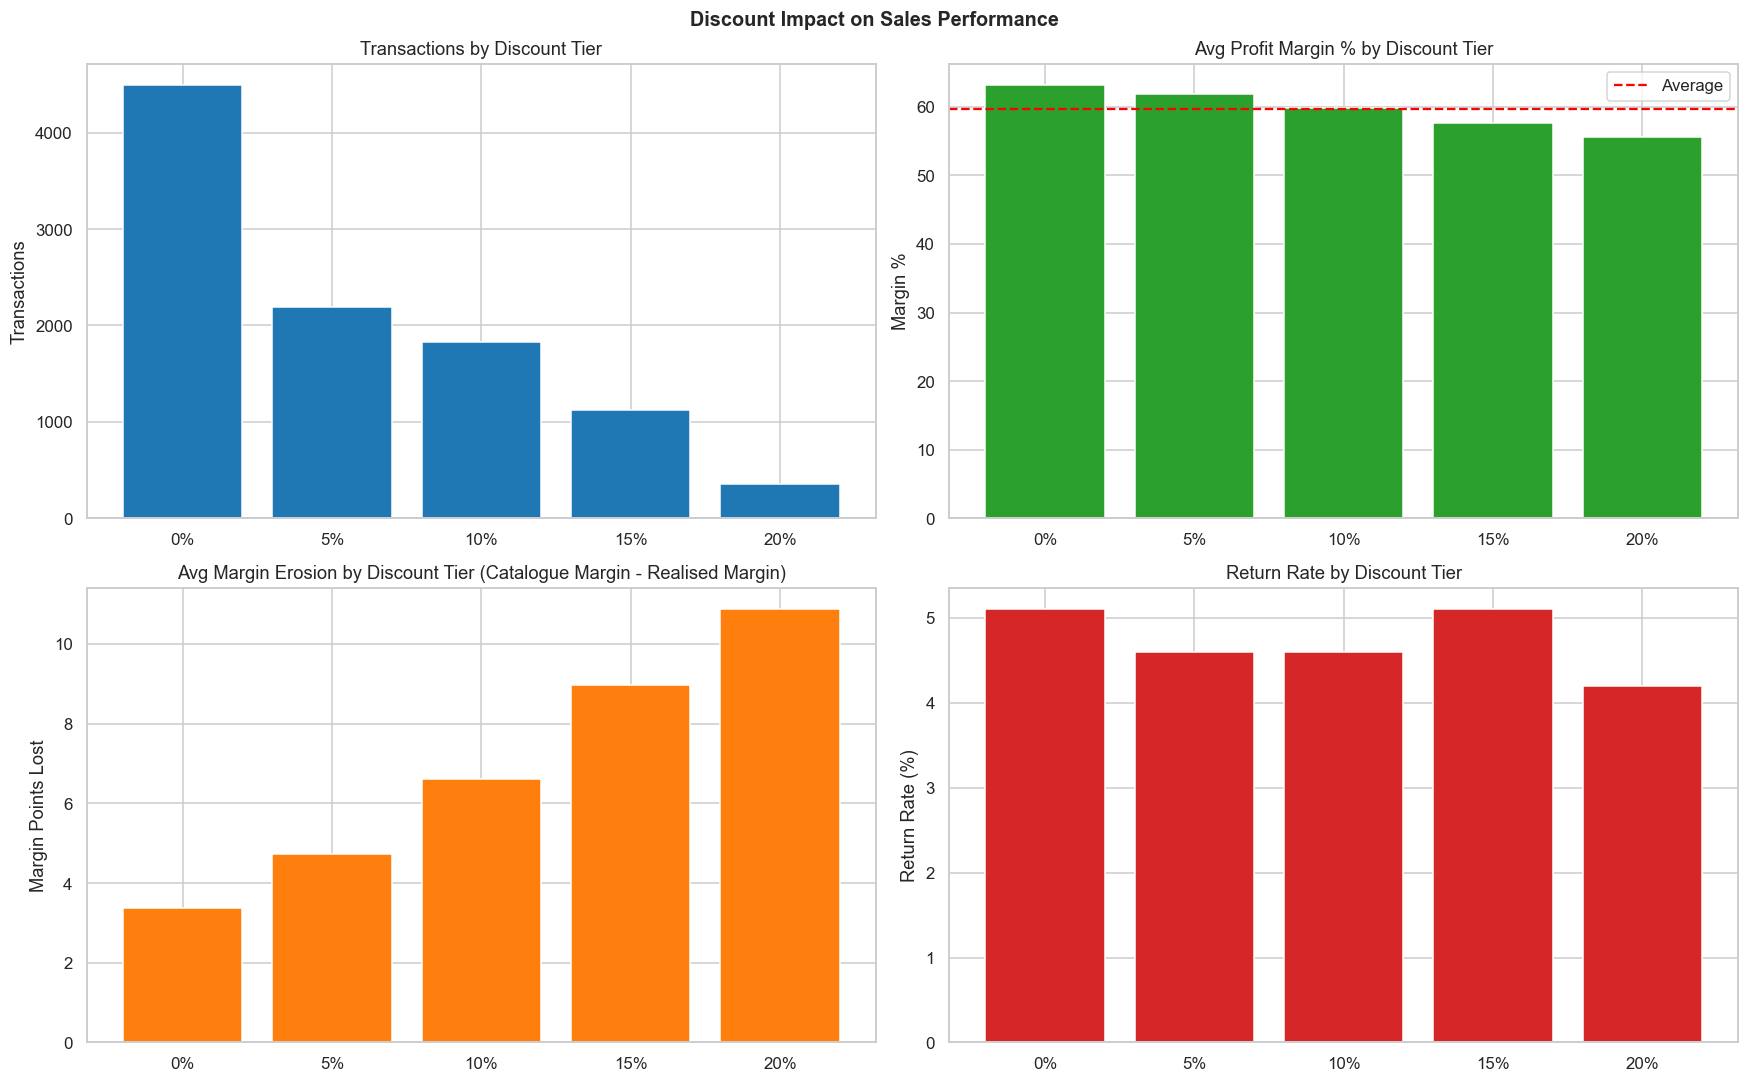

In [10]:
discount = sales.groupby('discount_pct').agg(
    transactions   = ('sale_id', 'count'),
    avg_units_sold = ('quantity_sold', 'mean'),
    avg_net_profit = ('net_profit', 'mean'),
    avg_margin     = ('profit_margin_pct', 'mean'),
    avg_erosion    = ('margin_erosion', 'mean'),
    return_rate    = ('is_returned', 'mean')
).reset_index()
discount['return_rate'] = (discount['return_rate'] * 100).round(1)

print("Discount Tier Analysis:")
print(discount.to_string(index=False))

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
x = discount['discount_pct'].astype(str) + '%'

# Top-left: transaction volume at each discount tier
axes[0, 0].bar(x, discount['transactions'], color=BLUE)
axes[0, 0].set_title("Transactions by Discount Tier")
axes[0, 0].set_ylabel("Transactions")

# Top-right: avg margin % at each tier; dashed line marks the overall average
axes[0, 1].bar(x, discount['avg_margin'], color=GREEN)
axes[0, 1].axhline(discount['avg_margin'].mean(), color='red', linestyle='--', label='Average')
axes[0, 1].set_title("Avg Profit Margin % by Discount Tier")
axes[0, 1].set_ylabel("Margin %")
axes[0, 1].legend()

# Bottom-left: margin erosion — actual margin points lost vs catalogue price
axes[1, 0].bar(x, discount['avg_erosion'], color=ORANGE)
axes[1, 0].set_title("Avg Margin Erosion by Discount Tier (Catalogue Margin - Realised Margin)")
axes[1, 0].set_ylabel("Margin Points Lost")

# Bottom-right: return rate — does discounting cause more returns?
axes[1, 1].bar(x, discount['return_rate'], color=RED)
axes[1, 1].set_title("Return Rate by Discount Tier")
axes[1, 1].set_ylabel("Return Rate (%)")

plt.suptitle("Discount Impact on Sales Performance", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**What the charts show:**

- The **0 percent discount tier** has the most transactions, with almost **4450**. This is about twice the number of transactions in the **5 percent tier** at around **2200**, and about thirteen times more than the **20 percent tier** at around **350**. As the discount increases, the number of transactions decreases. **The 20 percent discount** is used very rarely.

- **Profit margin** decreases gradually as the discount increases, but it still stays strong. The margin is about **63 percent** with no discount and falls to about **56 percent** at the **20 percent discount** level. The average margin is around **60 percent**. Even with the largest discount, the margin stays above **55 percent**, meaning discounts are not pushing any sales into very low margin levels.

- **Margin erosion** shows the difference between the margin the business expects to earn and the margin it actually earns. At **0 percent discount**, about **3.4 margin points** are already lost, mainly because of returns. At the **20 percent discount** level, about **13.5 margin points** are lost. This represents the real cost of offering each discount level.

- **Return rates** do not increase as discounts get larger. In fact, the **20 percent discount tier** has the lowest return rate at about **4.2 percent**, while the **0 percent discount tier** has the highest at about **5.2 percent**. This suggests that customers who receive discounts are not more likely to return items, and discounts are not leading to low quality purchases.


## Customer EDA

200 customers enriched with RFM scores from the feature engineering notebook.
This section profiles the customer base who they are, how they behave,
and what separates high-value segments from lower-value ones.

#### 1. Customer Demographics

Age distribution, gender split, and age group breakdown across the 200 customers.

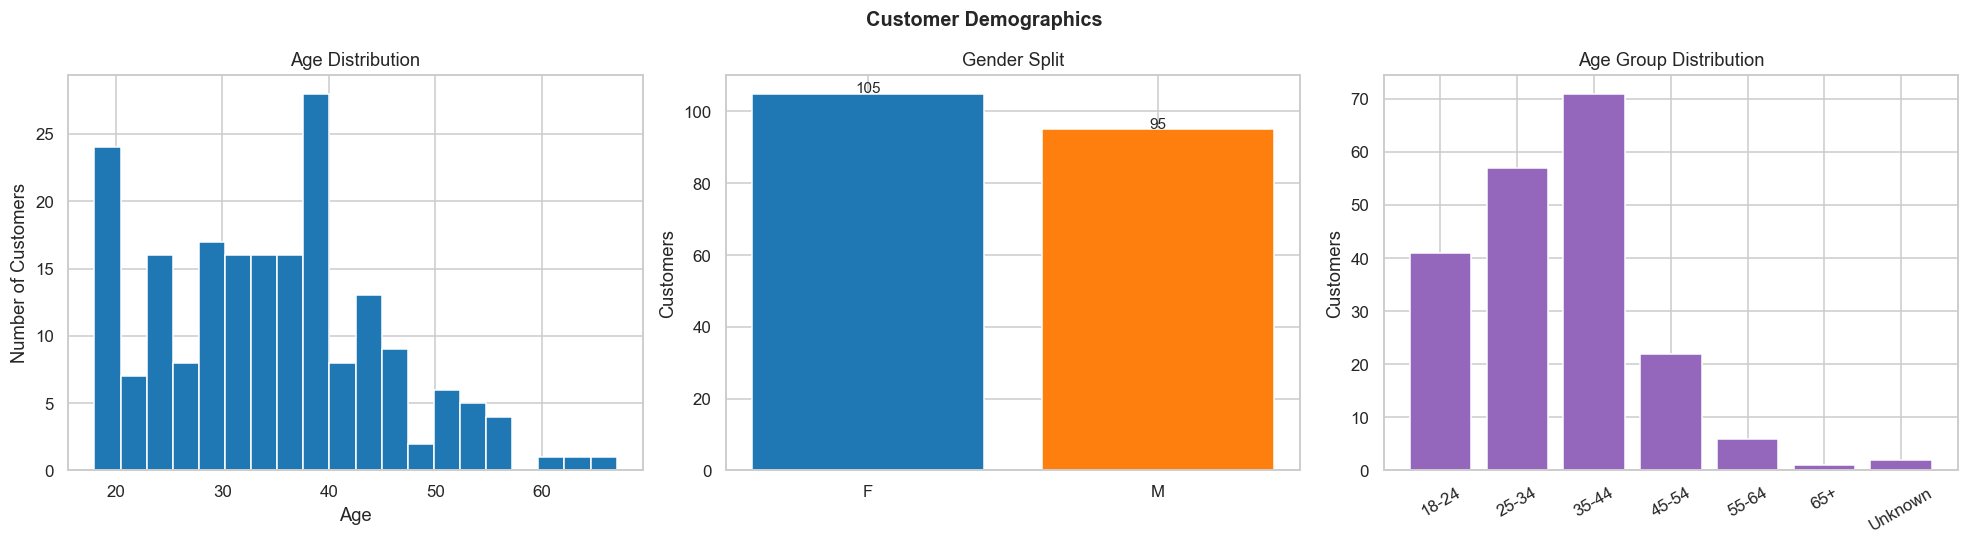

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Chart 1: Age histogram — bins=20 groups ages into 20 buckets
axes[0].hist(customers['age'].dropna(), bins=20, color=BLUE, edgecolor='white')
axes[0].set_title("Age Distribution")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Number of Customers")

# Chart 2: Gender split — simple bar with count labels on top
gender_counts = customers['gender'].value_counts()
axes[1].bar(gender_counts.index, gender_counts.values, color=[BLUE, ORANGE])
axes[1].set_title("Gender Split")
axes[1].set_ylabel("Customers")
for bar, val in zip(axes[1].patches, gender_counts.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                 str(val), ha='center')

# Chart 3: Age group — reindex forces logical age order, not alphabetical
age_order = ['18-24', '25-34', '35-44', '45-54', '55-64', '65+', 'Unknown']
age_counts = customers['age_group'].value_counts().reindex(age_order).dropna()
axes[2].bar(age_counts.index, age_counts.values, color=PURPLE)
axes[2].set_title("Age Group Distribution")
axes[2].set_ylabel("Customers")
axes[2].tick_params(axis='x', rotation=30)

plt.suptitle("Customer Demographics", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**What the charts show:**

- The age distribution is **highest** around **38 to 40** years old and is slightly right skewed. Most customers are in their 30s and 40s. The number of customers gradually decreases after age 50, and there are very few customers aged 55 and above.

- The **gender split is almost even**, with **105 female** customers and **95 male** customers.

- The **age group chart** shows that the **35 to 44 group** is the **largest with about 71 customers**. This is followed by the 25 to 34 group with about 57 customers, and the 18 to 24 group with about 41 customers. Customers aged 45 to 54 are about 22, and the 55 plus group is very small.

This suggests that StyleSense's main customers are adults in their 30s and 40s. Marketing messages, product choices, and promotions should mainly focus on this group.

#### 2. RFM Segment Analysis

Each customer was scored on Recency, Frequency, and Monetary value and assigned
to one of five segments. Here we compare how each segment performs across all
four metrics to validate the segmentation and identify priorities.

RFM Segment Profile:
RFM_segment  count  avg_recency  avg_orders  avg_spent  avg_tenure
   Champion     12          3.2        63.9     5026.6       535.5
      Loyal     66          6.2        53.6     3910.6       535.0
  Potential     54         13.3        49.9     3337.5       526.6
    At Risk     42         13.6        45.4     2693.3       526.9
       Lost     26         25.2        41.8     2320.9       518.1


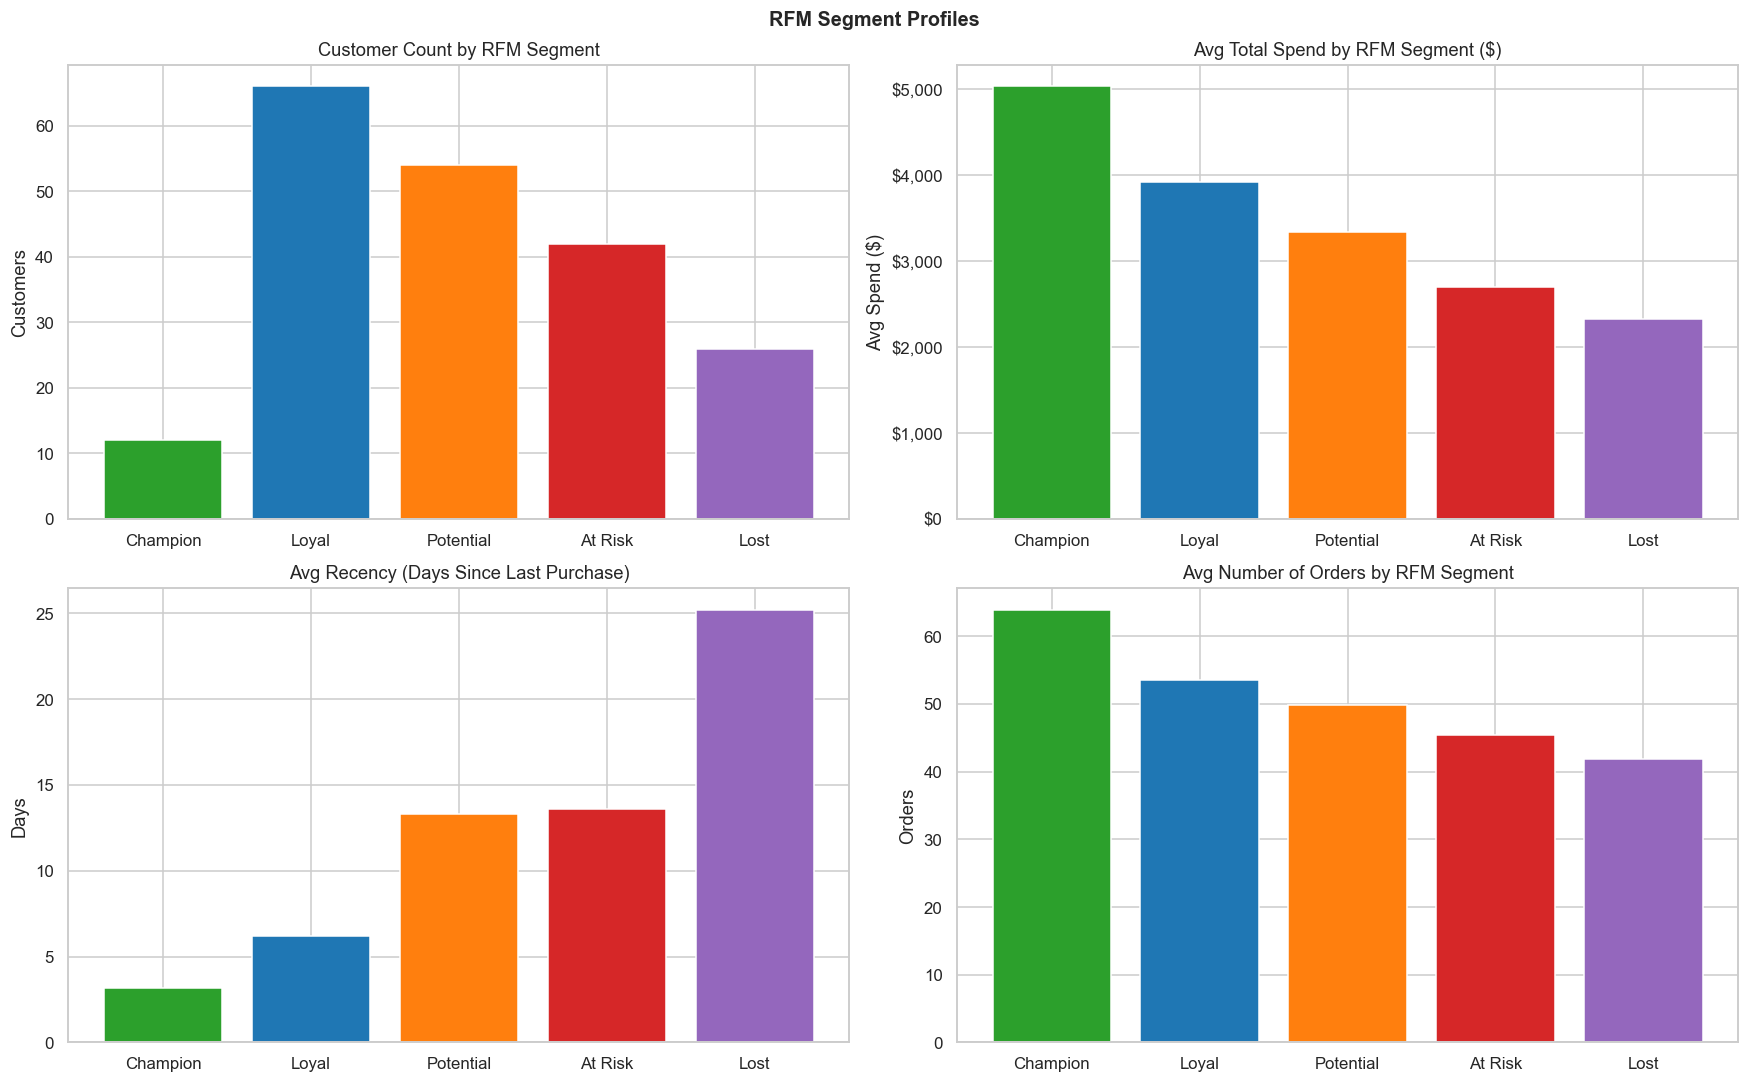

In [12]:
rfm_profile = customers.groupby('RFM_segment').agg(
    count       = ('customer_id', 'count'),
    avg_recency = ('recency_days', 'mean'),
    avg_orders  = ('num_orders', 'mean'),
    avg_spent   = ('total_spent', 'mean'),
    avg_tenure  = ('tenure_days', 'mean')
).round(1).reset_index()

seg_order = ['Champion', 'Loyal', 'Potential', 'At Risk', 'Lost']
rfm_profile['RFM_segment'] = pd.Categorical(rfm_profile['RFM_segment'], categories=seg_order, ordered=True)
rfm_profile = rfm_profile.sort_values('RFM_segment')

print("RFM Segment Profile:")
print(rfm_profile.to_string(index=False))

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
colors = [GREEN, BLUE, ORANGE, RED, PURPLE]

# Top-left: how many customers are in each segment?
axes[0, 0].bar(rfm_profile['RFM_segment'], rfm_profile['count'], color=colors)
axes[0, 0].set_title("Customer Count by RFM Segment")
axes[0, 0].set_ylabel("Customers")

# Top-right: average total lifetime spend per segment
axes[0, 1].bar(rfm_profile['RFM_segment'], rfm_profile['avg_spent'], color=colors)
axes[0, 1].set_title("Avg Total Spend by RFM Segment ($)")
axes[0, 1].set_ylabel("Avg Spend ($)")
axes[0, 1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

# Bottom-left: average recency days — lower means more recently active
axes[1, 0].bar(rfm_profile['RFM_segment'], rfm_profile['avg_recency'], color=colors)
axes[1, 0].set_title("Avg Recency (Days Since Last Purchase)")
axes[1, 0].set_ylabel("Days")

# Bottom-right: average number of orders placed
axes[1, 1].bar(rfm_profile['RFM_segment'], rfm_profile['avg_orders'], color=colors)
axes[1, 1].set_title("Avg Number of Orders by RFM Segment")
axes[1, 1].set_ylabel("Orders")

plt.suptitle("RFM Segment Profiles", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**What the charts show:**

The RFM segmentation is performing as expected, metrics decline clearly from Champion to Lost.

- **Champions (12 customers)**: Smallest group but highest value. Avg spend $5,050, avg 64 orders, only 3 days since last purchase. Most active and highest-spending customers.

- **Loyal (66 customers)**: Largest group. Avg spend $3,950, avg 54 orders, 6 days since last purchase. Strong, consistent buyers.

- **At Risk (42 customers)**: Important segment to watch. Recency (14 days) similar to Potential (13), but lower spend ($2,700) and orders (46). Decent buyers showing early drift.

- **Lost (26 customers)**: Avg 25 days since last purchase, lowest spend ($2,350) and fewest orders (42). Re-engagement ROI is low.

    
**Priority actions**:

- **Retention focus**: Champions + Loyals (78 customers) generate the most value.

- **Win-back focus**: At Risk (42 customers) need targeted efforts before drifting further.

#### 3. Spending Distribution & Lifetime Value

How is spending spread across the 200 customers? Does ordering more
mean spending more? Does being a longer-tenured customer mean spending more?

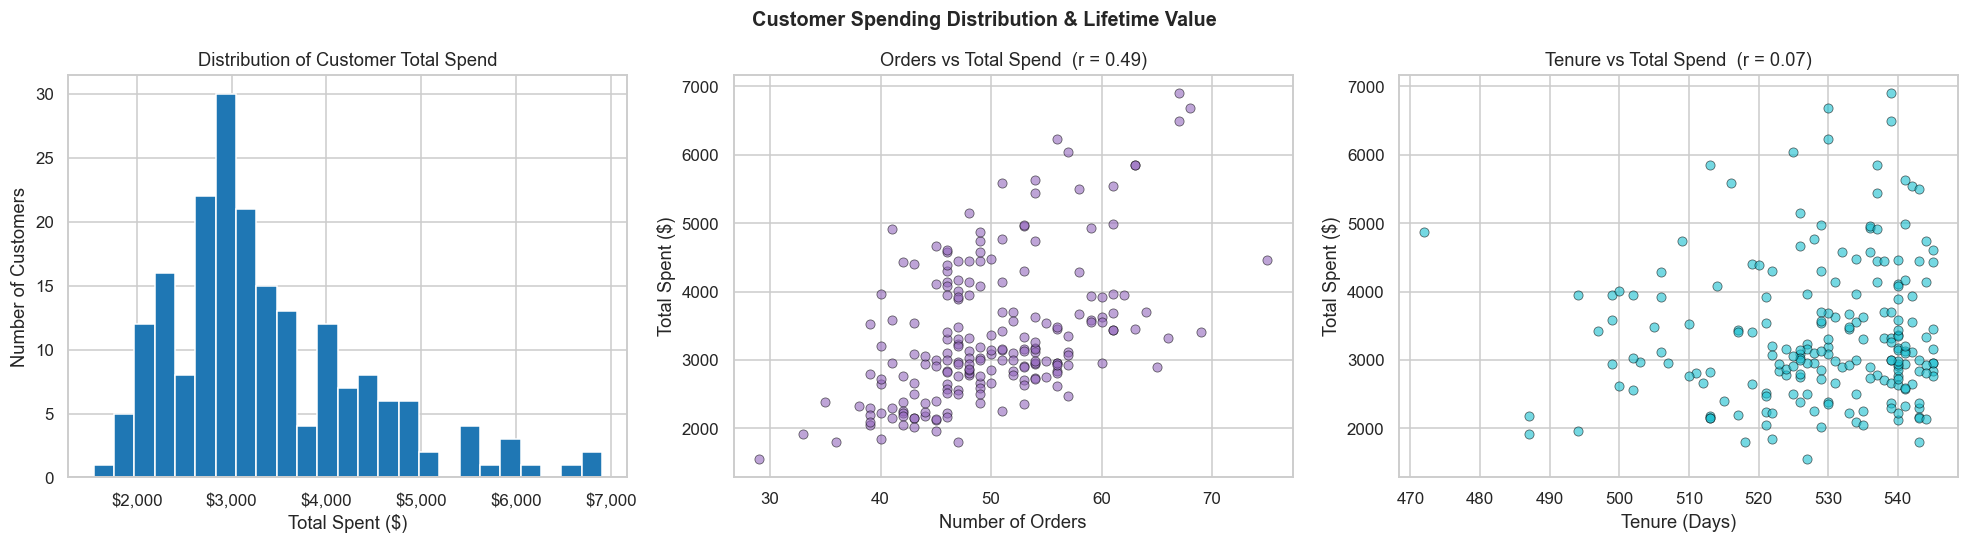

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Chart 1: Distribution of total lifetime spend
axes[0].hist(customers['total_spent'], bins=25, color=BLUE, edgecolor='white')
axes[0].set_title("Distribution of Customer Total Spend")
axes[0].set_xlabel("Total Spent ($)")
axes[0].set_ylabel("Number of Customers")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

# Chart 2: Orders vs total spend scatter
# r = Pearson correlation; 1.0 = perfect positive, 0.0 = no relationship
corr = customers['num_orders'].corr(customers['total_spent'])
axes[1].scatter(customers['num_orders'], customers['total_spent'], alpha=0.6,
                color=PURPLE, edgecolors='black', linewidths=0.5)
axes[1].set_title(f"Orders vs Total Spend  (r = {corr:.2f})")
axes[1].set_xlabel("Number of Orders")
axes[1].set_ylabel("Total Spent ($)")

# Chart 3: Tenure vs total spend scatter
# tenure_days = days between first and last purchase
corr2 = customers['tenure_days'].corr(customers['total_spent'])
axes[2].scatter(customers['tenure_days'], customers['total_spent'], alpha=0.6,
                color=TEAL, edgecolors='black', linewidths=0.5)
axes[2].set_title(f"Tenure vs Total Spend  (r = {corr2:.2f})")
axes[2].set_xlabel("Tenure (Days)")
axes[2].set_ylabel("Total Spent ($)")

plt.suptitle("Customer Spending Distribution & Lifetime Value", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**What the charts show:**

**Spending is concentrated around $2,800–$3,000** that is the peak of the histogram.
The distribution is right-skewed, meaning most customers spend in the $2,000–$4,000 range
with a smaller group of high spenders reaching up to ~$7,000.

**Orders vs spend (r = 0.49):** a moderate positive correlation, customers who place
more orders tend to spend more overall, but the scatter is wide. Placing more orders
is a reasonable predictor of higher spend, but it is not a strong one on its own.

**Tenure vs spend (r = 0.07):** essentially zero relationship. How long someone has
been a customer (measured by the gap between their first and last purchase) has almost
no bearing on how much they spend. Being an 'older' customer does not automatically
make someone a higher spender, behaviour matters more than duration.

#### 4. Favourite Category & Geography

Which product categories do customers gravitate toward, and which states have
the highest concentration of StyleSense customers?

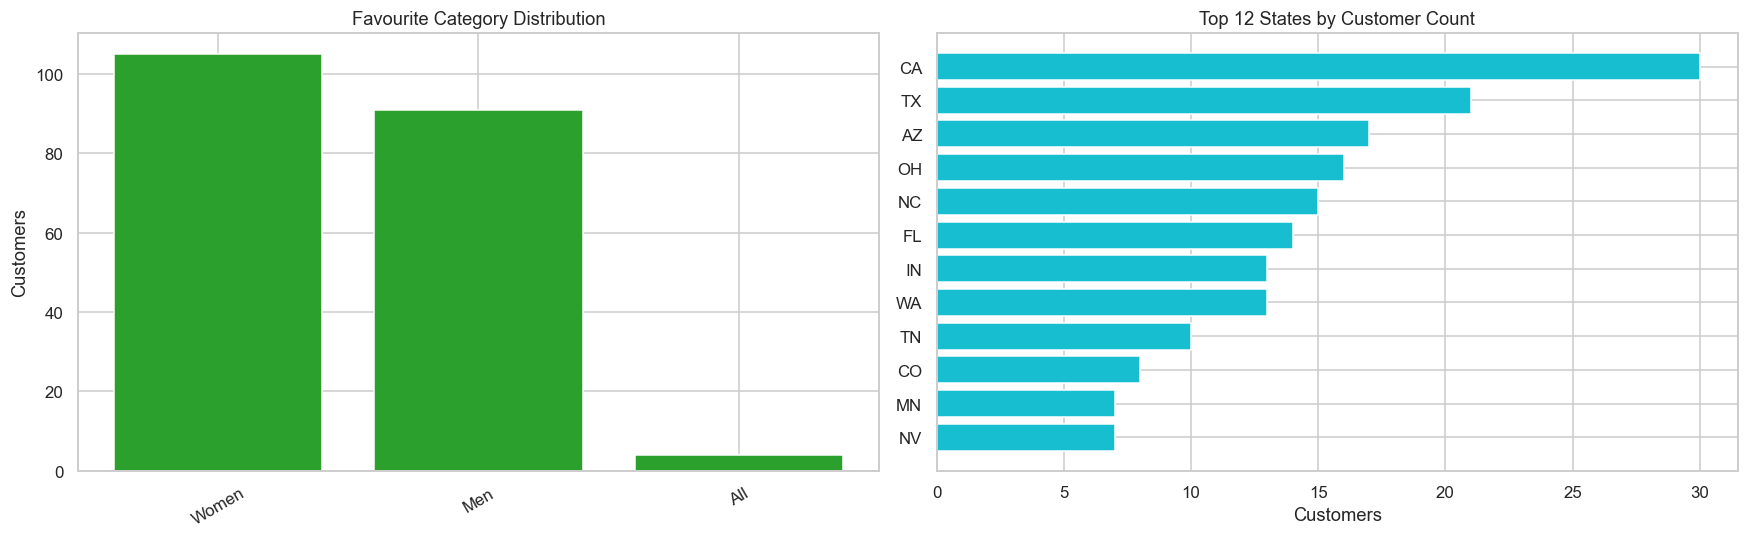

Top 2 favourite categories by RFM segment:
RFM_segment favourite_category  count
    At Risk              Women     22
    At Risk                Men     19
   Champion              Women      8
   Champion                Men      4
       Lost              Women     13
       Lost                Men     12
      Loyal                Men     36
      Loyal              Women     28
  Potential              Women     34
  Potential                Men     20


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Chart 1: Favourite category — how many customers listed each as their favourite
fav_cat = customers['favourite_category'].value_counts()
axes[0].bar(fav_cat.index, fav_cat.values, color=GREEN)
axes[0].set_title("Favourite Category Distribution")
axes[0].set_ylabel("Customers")
axes[0].tick_params(axis='x', rotation=30)

# Chart 2: Top 12 states — [::-1] reverses so the longest bar appears at the top
top_states = customers['state'].value_counts().head(12)
axes[1].barh(top_states.index[::-1], top_states.values[::-1], color=TEAL)
axes[1].set_title("Top 12 States by Customer Count")
axes[1].set_xlabel("Customers")

plt.tight_layout()
plt.show()

# Top 2 favourite categories per RFM segment
print("Top 2 favourite categories by RFM segment:")
print(customers.groupby(['RFM_segment', 'favourite_category']).size()
      .reset_index(name='count')
      .sort_values(['RFM_segment', 'count'], ascending=[True, False])
      .groupby('RFM_segment').head(2)
      .to_string(index=False))

**What the charts show:**

**Women's is the most popular category by far** **105 customers** list it as their
favourite, compared to **91 for Men's**. Only **4 customers** favour the 'All' category
(accessories/unisex), and no customers listed Kids as a favourite. 
    
This matters: the Kids products exist in the catalogue and generate revenue, but no customer
considers Kids their primary interest, they are likely being bought by parents who primarily identify as Women's or Men's shoppers.

**California dominates geographically** with **30 customers** well ahead of **Texas (21)**
and **Arizona (17)**. 

The **top 12 states** are spread across the country, suggesting
**StyleSense's customer base is nationally distributed** rather than regionally concentrated.


##  Product EDA

25 products across four categories (Men, Women, Kids, All/accessories).
This section examines whether price predicts margin, and ranks all products
by their catalogue profit margin.

In [15]:
print("Products by category:")
print(products['category'].value_counts().to_string())
print()
print("Products by season:")
print(products['season'].value_counts().to_string())
print()
print("Price and margin summary across all 25 products:")
print(products[['base_price', 'cost_price', 'profit_per_unit', 'profit_margin_pct']].describe().round(2))

Products by category:
category
Women    9
Men      8
Kids     4
All      4

Products by season:
season
All       13
Winter     6
Summer     6

Price and margin summary across all 25 products:
       base_price  cost_price  profit_per_unit  profit_margin_pct
count       25.00       25.00            25.00               25.0
mean        40.59       14.42            26.17               65.6
std         20.22        8.02            12.23                3.2
min          9.99        2.50             7.49               61.1
25%         24.99        9.00            16.99               63.6
50%         39.99       14.00            25.99               64.4
75%         49.99       18.00            31.99               66.7
max         89.99       35.00            54.99               75.0


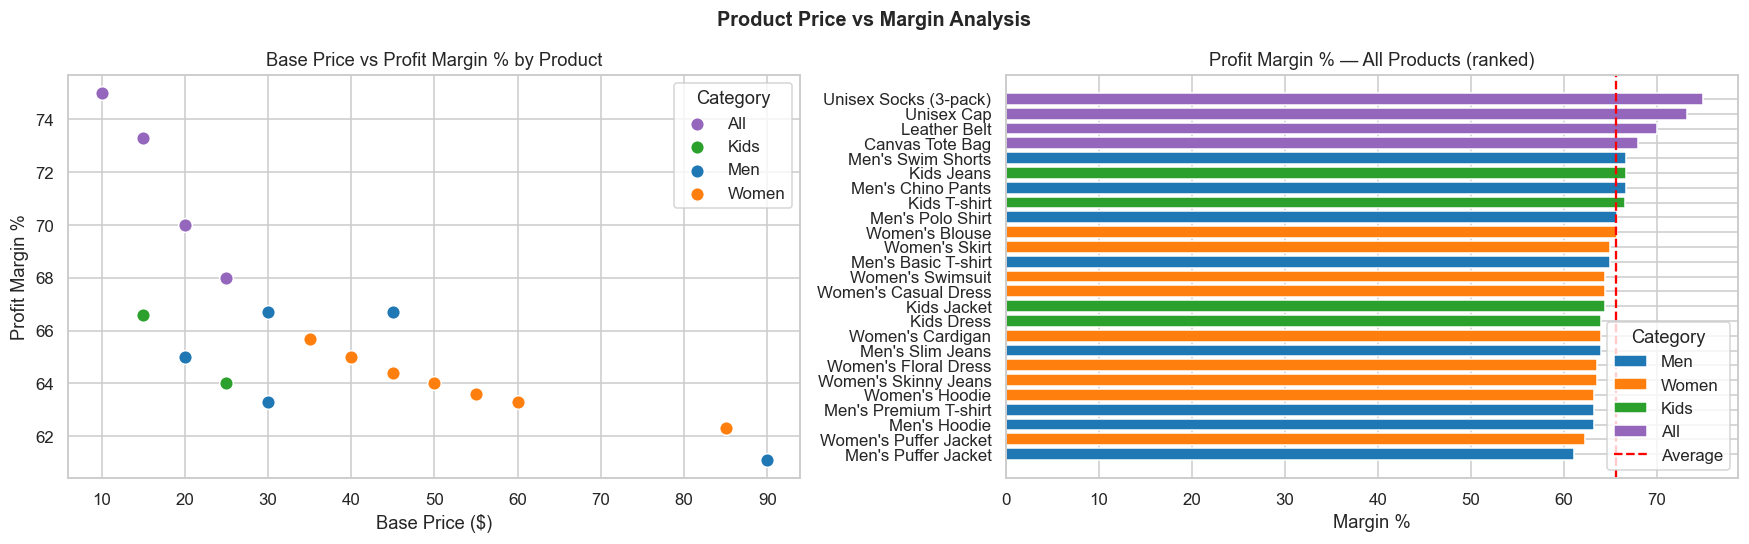

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Scatter: base price vs profit margin %, coloured by category
cat_colors = {'Men': BLUE, 'Women': ORANGE, 'Kids': GREEN, 'All': PURPLE}
for cat, grp in products.groupby('category'):
    axes[0].scatter(grp['base_price'], grp['profit_margin_pct'],
                    label=cat, color=cat_colors[cat], s=80, edgecolors='white')
axes[0].set_title("Base Price vs Profit Margin % by Product")
axes[0].set_xlabel("Base Price ($)")
axes[0].set_ylabel("Profit Margin %")
axes[0].legend(title="Category")

# Horizontal bar: all 25 products ranked lowest to highest margin
# Average line added for reference
prod_sorted = products.sort_values('profit_margin_pct')
colors_bar  = [cat_colors[c] for c in prod_sorted['category']]
axes[1].barh(prod_sorted['product_name'], prod_sorted['profit_margin_pct'], color=colors_bar)
axes[1].axvline(products['profit_margin_pct'].mean(), color='red', linestyle='--', label='Average')
axes[1].set_title("Profit Margin % — All Products (ranked)")
axes[1].set_xlabel("Margin %")
axes[1].legend()

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=cat_colors[c], label=c) for c in cat_colors]
axes[1].legend(handles=legend_elements + [plt.Line2D([0],[0],color='red',linestyle='--',label='Average')],
               title="Category")

plt.suptitle("Product Price vs Margin Analysis", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**What the charts show:**

Price and margin are inversely related — cheaper products earn higher margins.

- **Accessories (All category, purple dots):** Low prices ($9–$25) but top margins (70–76%) due to low costs.

- **Expensive items:**  Men's Puffer Jacket ($90) and  Women's Puffer Jacket ($60) have low margins because high production costs compress profits.

    
Ranked bar chart highlights:

- **Top margin products:** Unisex Socks 3-pack (75%), Unisex Cap (74%), Leather Belt (70%), Canvas Tote Bag (69%) — all accessories.

- **Lowest margin products:** Men's Puffer Jacket (61%), Women's Puffer Jacket (63%), Men's Hoodie (63%) - higher-cost items.

- **Overall spread:** 61%–75% across 25 products; the catalog is profitable.


##  Expenses EDA

Expenses are classified as fixed (Rent, Insurance, Software) or variable
(COGS, Payroll, Marketing, Shipping, Utilities). This section examines
the cost structure and how costs behave month to month.

Fixed vs Variable Cost Split:
                 sum     mean   pct
cost_type                          
Fixed       72900.00  1350.00  13.3
Variable   474579.42   374.27  86.7

By Category:
                category cost_type    amount
      Cost of Goods Sold  Variable 249989.00
                 Payroll  Variable 187300.32
                    Rent     Fixed  63000.00
    Shipping & Packaging  Variable  15870.57
               Marketing  Variable  15064.49
               Insurance     Fixed   7200.00
               Utilities  Variable   6355.04
Software & Subscriptions     Fixed   2700.00


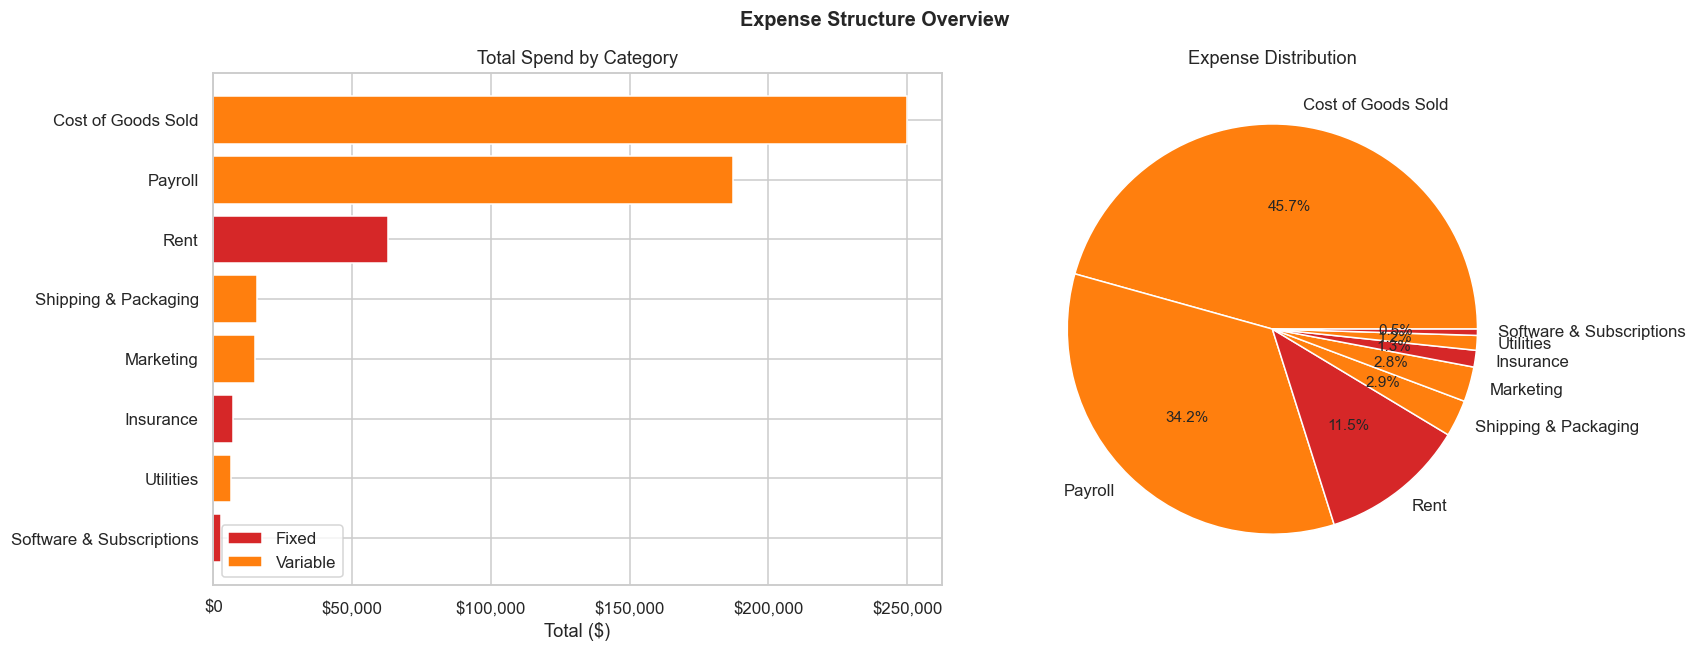

In [17]:
# Fixed vs variable split and breakdown by individual category
cost_split = expenses.groupby('cost_type')['amount'].agg(['sum', 'mean']).round(2)
cost_split['pct'] = (cost_split['sum'] / cost_split['sum'].sum() * 100).round(1)
print("Fixed vs Variable Cost Split:")
print(cost_split.to_string())
print()

cat_exp = expenses.groupby(['category', 'cost_type'])['amount'].sum().reset_index()
cat_exp = cat_exp.sort_values('amount', ascending=False)
print("By Category:")
print(cat_exp.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Horizontal bar: total spend by category; red = fixed, orange = variable
axes[0].barh(cat_exp['category'][::-1], cat_exp['amount'][::-1],
             color=[RED if t == 'Fixed' else ORANGE for t in cat_exp['cost_type'][::-1]])
axes[0].set_title("Total Spend by Category")
axes[0].set_xlabel("Total ($)")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
from matplotlib.patches import Patch
axes[0].legend(handles=[Patch(facecolor=RED, label='Fixed'), Patch(facecolor=ORANGE, label='Variable')])

# Pie: proportion of total expenses by category
axes[1].pie(cat_exp['amount'], labels=cat_exp['category'], autopct='%1.1f%%',
            colors=[ORANGE, ORANGE, RED, ORANGE, ORANGE, RED, ORANGE, RED])
axes[1].set_title("Expense Distribution")

plt.suptitle("Expense Structure Overview", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**What the charts show:**

- **COGS** is the **largest expense (~$250k / 45.7%)** - expected for a retailer since every item has a direct cost.

- **Payroll** is second (~$185k / 34.2%) - together with COGS, they make up ~80% of total expenses.

- **Other expenses** (~$65k / 11.5% **rent** + **shipping**, **marketing**, **insurance**, **utilities**, **software**) make up the remaining ~20%.

Fixed costs are small (~13–14% of total) ~ mostly rent, insurance, software. The business is mainly variable-cost, so costs scale with sales. Payroll is variable too, so staffing must adjust as sales change.

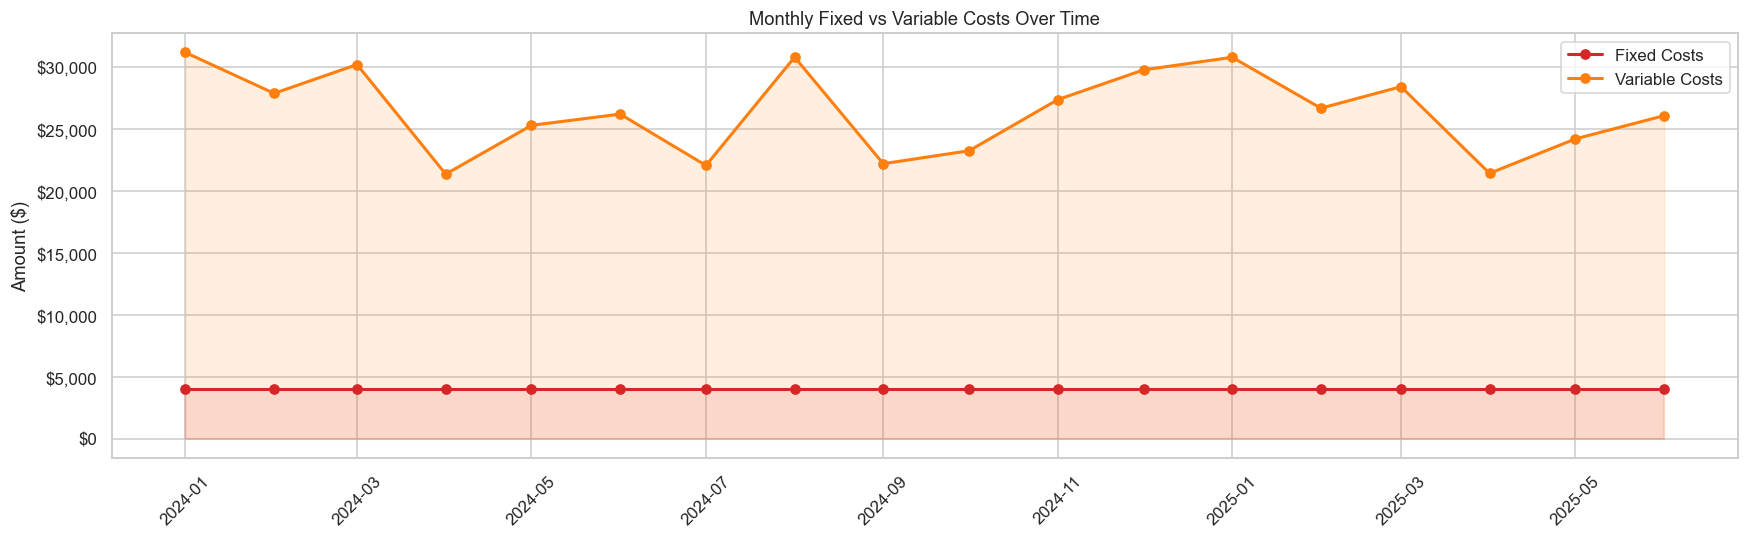

In [18]:
# Monthly fixed vs variable cost trend
monthly_exp = expenses.groupby(['month', 'cost_type'])['amount'].sum().reset_index()
monthly_exp['month_dt'] = monthly_exp['month'].dt.to_timestamp()

fixed_m    = monthly_exp[monthly_exp['cost_type'] == 'Fixed']
variable_m = monthly_exp[monthly_exp['cost_type'] == 'Variable']

fig, ax = plt.subplots(figsize=(16, 5))

# Fixed costs should form a flat horizontal line — any spike would signal an anomaly
ax.plot(fixed_m['month_dt'],    fixed_m['amount'],    color=RED,    marker='o', linewidth=2, label='Fixed Costs')
# Variable costs should move with sales activity — higher in busy months
ax.plot(variable_m['month_dt'], variable_m['amount'], color=ORANGE, marker='o', linewidth=2, label='Variable Costs')
ax.fill_between(fixed_m['month_dt'],    fixed_m['amount'],    alpha=0.12, color=RED)
ax.fill_between(variable_m['month_dt'], variable_m['amount'], alpha=0.12, color=ORANGE)
ax.set_title("Monthly Fixed vs Variable Costs Over Time")
ax.set_ylabel("Amount ($)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.legend()
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**What the chart shows:**

**Fixed costs (red line):** Flat at ~$4,000–$4,200/month over 18 months. Rent, Insurance, and Software are consistent with no anomalies.

**Variable costs (orange line):** Fluctuate ~$21k–$31k/month, peaking in high-revenue months (Jan 2024, Aug 2024, Jan 2025) and dipping in quieter months (Apr 2024, Sep 2024).

- **Healthy pattern:** Variable costs track sales, while fixed costs remain stable and predictable.


##  Inventory EDA

Daily stock levels for 25 products over 18 months.
This section uses the `stock_health` ratio and `days_until_stockout` feature
to identify how often products fall into risk territory and which ones
need the most attention.

Stock health summary (stock_level / reorder_point):
count    13675.00
mean         2.63
std          1.00
min          1.00
25%          1.78
50%          2.55
75%          3.35
max          5.00
Name: stock_health, dtype: float64

Records with stock_health < 1.0 (below reorder point): 0 (0.0%)
Records with is_near_stockout flag: 96


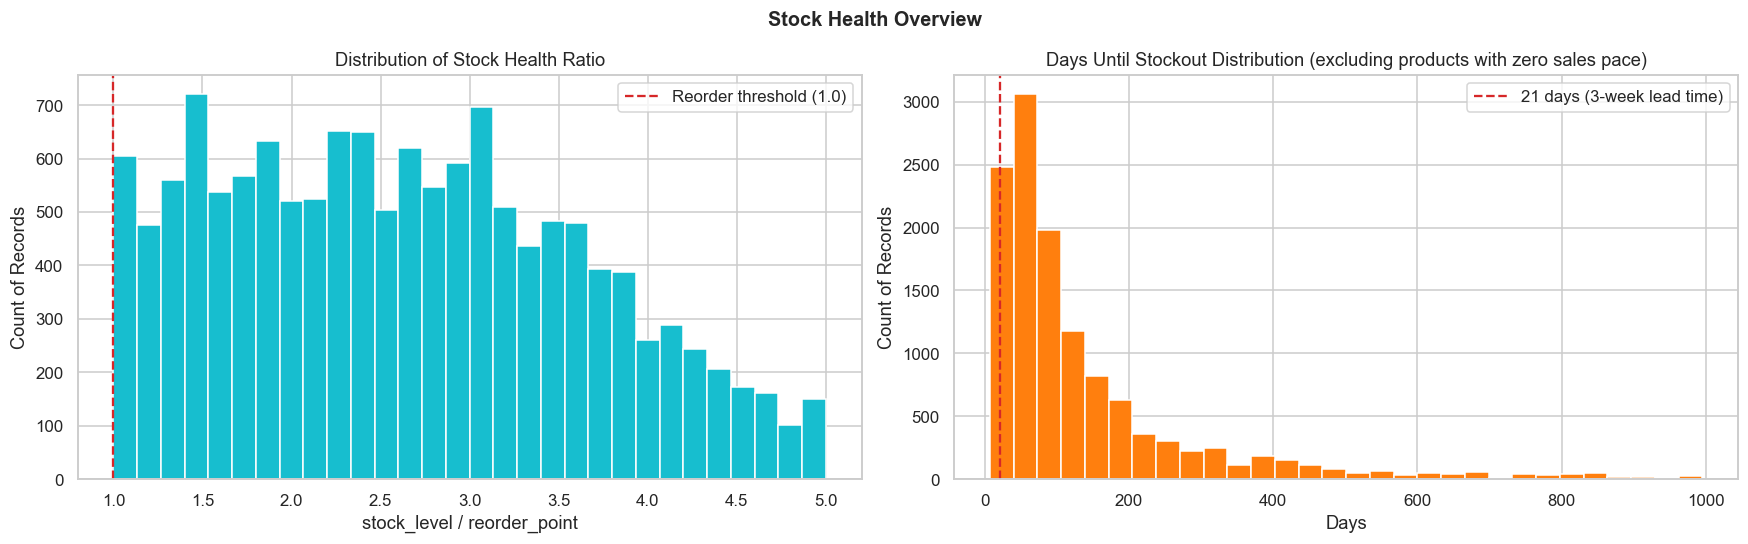

In [19]:
print("Stock health summary (stock_level / reorder_point):")
print(inventory['stock_health'].describe().round(2))
print()
print(f"Records with stock_health < 1.0 (below reorder point): "
      f"{(inventory['stock_health'] < 1.0).sum():,} "
      f"({(inventory['stock_health'] < 1.0).mean() * 100:.1f}%)")
print(f"Records with is_near_stockout flag: {inventory['is_near_stockout'].sum():,}")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Chart 1: Stock health distribution
# The red dashed line at 1.0 marks the reorder threshold
# Any bar to the left of it = stock already at or below the safe minimum
axes[0].hist(inventory['stock_health'], bins=30, color=TEAL, edgecolor='white')
axes[0].axvline(1.0, color=RED, linestyle='--', label='Reorder threshold (1.0)')
axes[0].set_title("Distribution of Stock Health Ratio")
axes[0].set_xlabel("stock_level / reorder_point")
axes[0].set_ylabel("Count of Records")
axes[0].legend()

# Chart 2: Days until stockout (excluding 999 = no active risk)
# Red dashed line marks 21 days — a typical 3-week supplier lead time
# Records to the left of this line need a reorder placed immediately
real_stockout = inventory[inventory['days_until_stockout'] < 999]['days_until_stockout']
axes[1].hist(real_stockout, bins=30, color=ORANGE, edgecolor='white')
axes[1].axvline(21, color=RED, linestyle='--', label='21 days (3-week lead time)')
axes[1].set_title("Days Until Stockout Distribution (excluding products with zero sales pace)")
axes[1].set_xlabel("Days")
axes[1].set_ylabel("Count of Records")
axes[1].legend()

plt.suptitle("Stock Health Overview", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**What the charts show:**

**Stock health distribution:** Most records sit between 1.0 and 3.0, with a reasonably
even spread across that range. The reorder threshold (1.0) is at the left edge,
the cluster of bars at 1.0–1.5 represents stock that is healthy but close to the
threshold. Records to the left of 1.0 are already in the danger zone.

**Days until stockout:** This chart is striking. The tallest bar is the leftmost one,
thousands of records fall *below the 21-day lead time line* (red dashed line).
This means that on many days, if no reorder had been placed, a significant number
of product-days would run out within the supplier lead time window.
The distribution is heavily right-skewed, with a long tail and most active-risk records
cluster in the 0–100 day range.

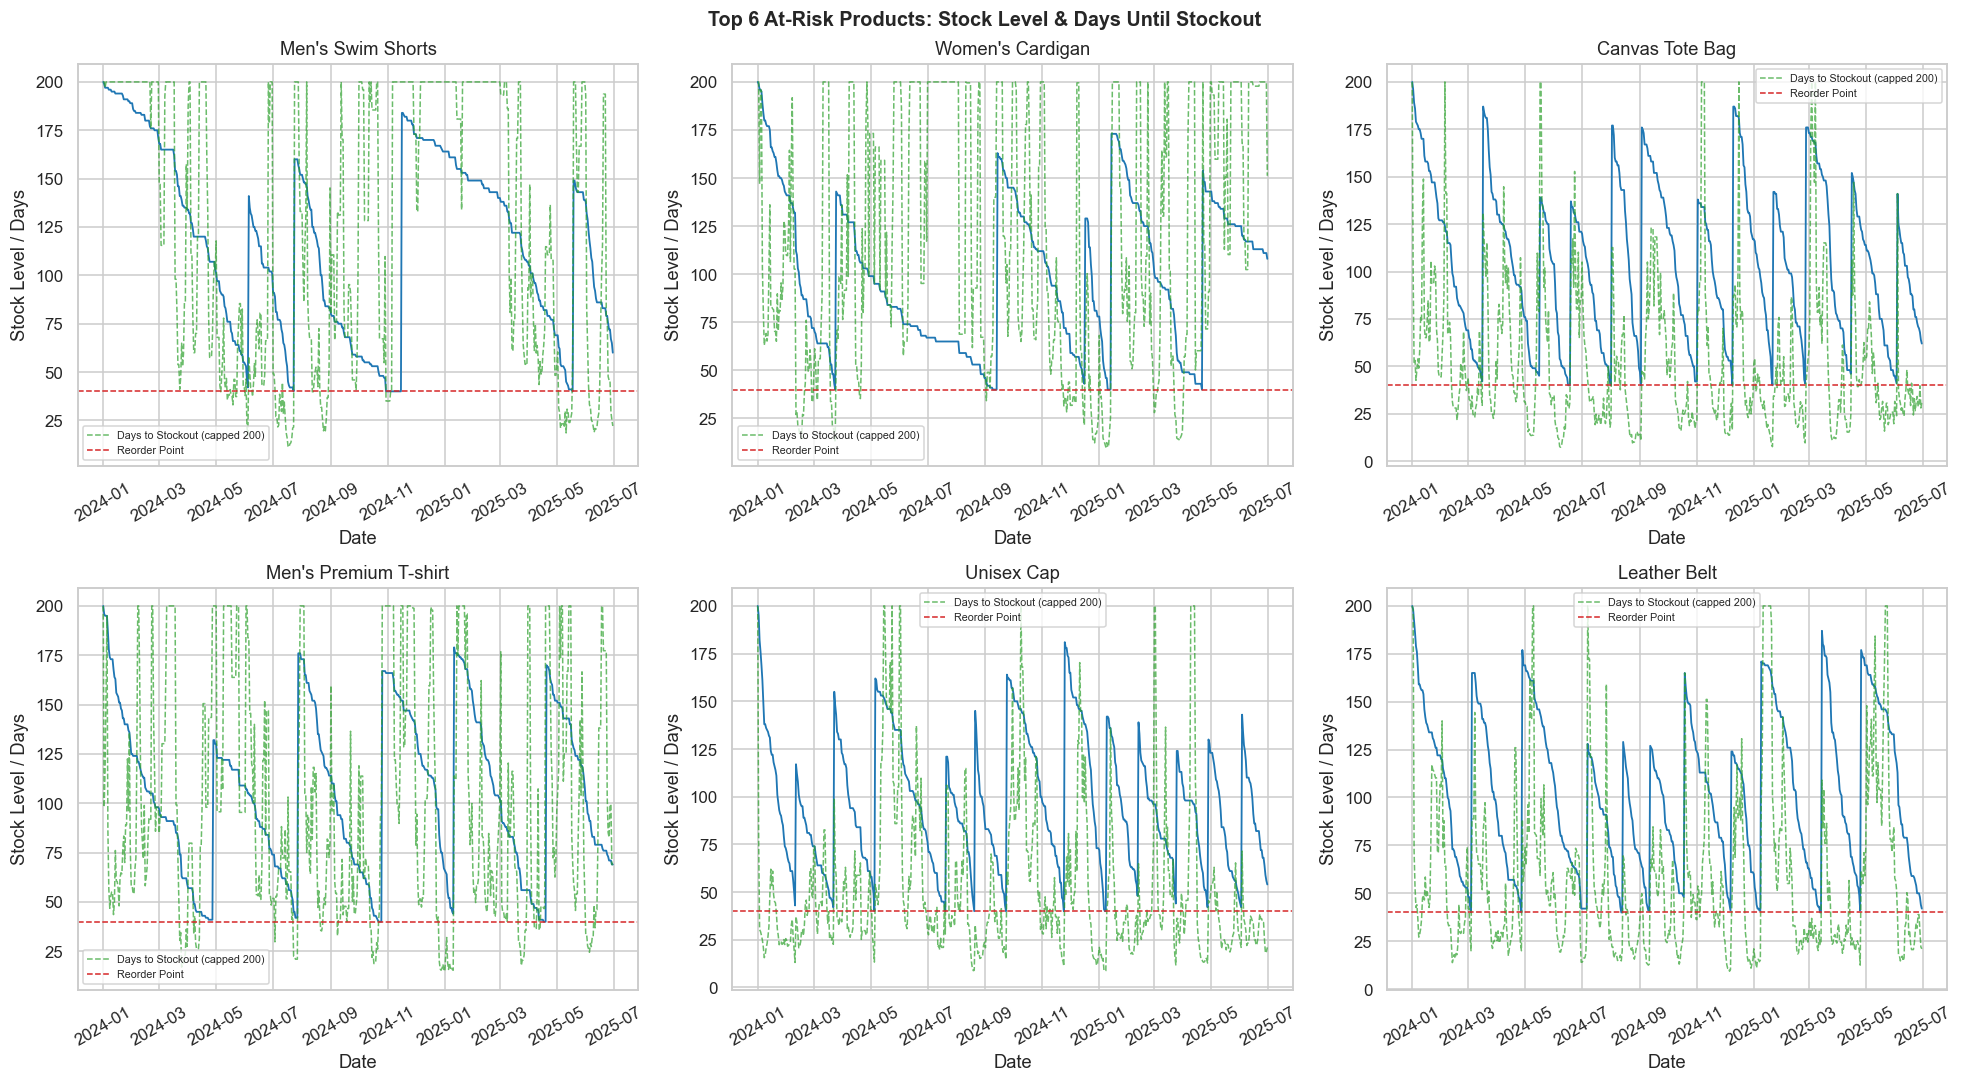

In [20]:
# The 6 products with the most cumulative days spent in near-stockout state
at_risk = inventory.groupby('product_name')['is_near_stockout'].sum().nlargest(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, product in enumerate(at_risk):
    prod_data = inventory[inventory['product_name'] == product].sort_values('date')
    # Blue solid line: actual stock level over time
    axes[i].plot(prod_data['date'], prod_data['stock_level'], color=BLUE, linewidth=1.2)
    # Green dashed line: days until stockout estimate (capped at 200 for chart readability)
    axes[i].plot(prod_data['date'], prod_data['days_until_stockout'].clip(upper=200),
                 color=GREEN, linewidth=1, linestyle='--', alpha=0.7, label='Days to Stockout (capped 200)')
    # Red dashed horizontal line: the fixed reorder point for this product
    axes[i].axhline(prod_data['reorder_point'].iloc[0], color=RED, linestyle='--',
                    linewidth=1, label='Reorder Point')
    axes[i].set_title(product)
    axes[i].set_xlabel("Date")
    axes[i].set_ylabel("Stock Level / Days")
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].legend(fontsize=7)

plt.suptitle("Top 6 At-Risk Products: Stock Level & Days Until Stockout", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**What the charts show:**

The 6 most at-risk products are: **Men's Swim Shorts, Women's Cardigan,
Canvas Tote Bag, Men's Premium T-shirt, Unisex Cap, and Leather Belt**.

All six show the same **sawtooth pattern**: stock depletes in a steady staircase
down to or below the red reorder line, then jumps sharply back up when a restock
arrives, then depletes again. This confirms that restocking is happening 
but reactively, not proactively.

**Men's Swim Shorts** shows the most severe and frequent dips below the reorder point.
The green dashed 'days to stockout' line spikes vertically just before each restock,
correctly signalling the approaching risk.

**What this means for operations:** these 6 products need earlier reorder triggers.
The current pattern of waiting until stock falls to the reorder point before ordering
leaves no buffer for supplier delays. Raising the reorder point or reducing the
reorder interval would reduce the frequency of dipping into the red zone.

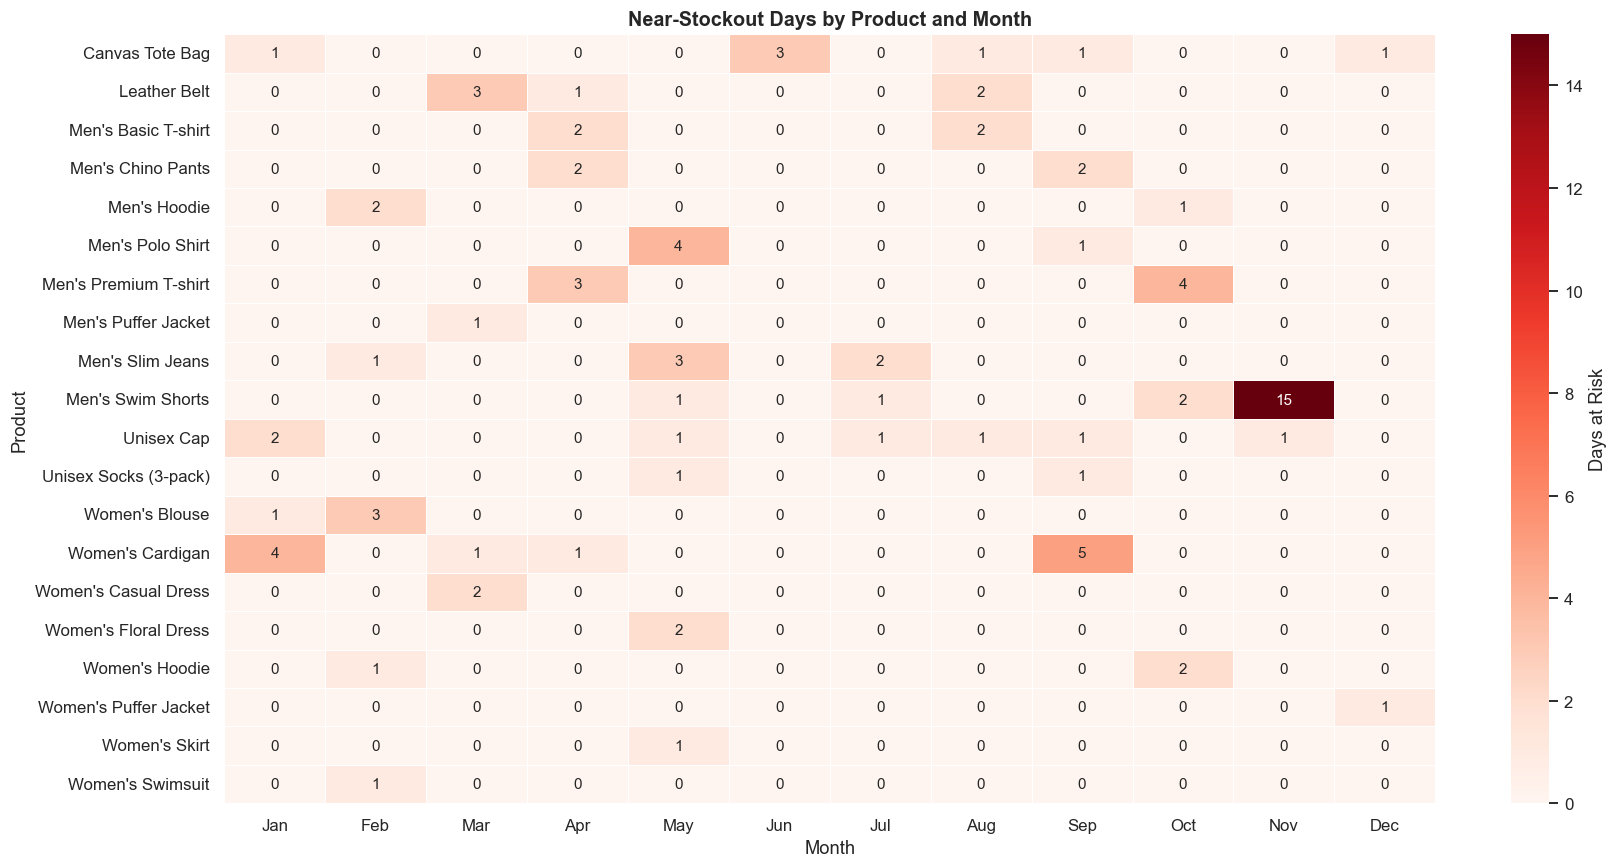

In [21]:
# Near-stockout heatmap: number of days each product spent at or below reorder point
# grouped by calendar month across the 18-month period
near_so = inventory[inventory['is_near_stockout']].copy()
near_so['month_num'] = near_so['date'].dt.month

heatmap_data  = near_so.groupby(['product_name', 'month_num']).size().reset_index(name='days_at_risk')
heatmap_pivot = heatmap_data.pivot(index='product_name', columns='month_num', values='days_at_risk').fillna(0)

month_names = {1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr', 5:'May', 6:'Jun',
               7:'Jul', 8:'Aug', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dec'}
heatmap_pivot.columns = [month_names.get(c, c) for c in heatmap_pivot.columns]

plt.figure(figsize=(16, 8))
sns.heatmap(heatmap_pivot, annot=True, fmt='.0f', cmap='Reds', linewidths=0.5,
            cbar_kws={'label': 'Days at Risk'})
plt.title("Near-Stockout Days by Product and Month", fontsize=13, fontweight='bold')
plt.xlabel("Month")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

**What the heatmap shows:**

Each cell shows how many days in that calendar month a product spent at or below
its reorder point. Darker red = more at-risk days. Empty cells = stock was healthy.

**The single most critical finding: Men's Swim Shorts in November ~ 15 days at risk.**
This is the darkest cell in the entire heatmap and stands far above everything else.
A summer product being critically low in November suggests either end-of-season
depletion without replenishment, or a late demand spike that was not anticipated.

**Other patterns to note:**
- **Women's Cardigan** has risk in two separate windows: January (4 days) and September (5 days),
  suggesting demand across multiple seasons
- **Men's Premium T-shirt** shows risk in April (3 days) and again in October (4 days)
- **Canvas Tote Bag** has 3 at-risk days in June
- **Most products show zeros** -the risk is concentrated in a small number of products
  and specific months, not spread across the whole catalogue
- **Kids products (Kids Jacket, Kids Jeans, Kids Dress) have zero at-risk days** throughout
  the entire period, their stock is consistently well managed


##  Cross-Dataset Relationships

The most revealing insights come from combining datasets:
1. Monthly P&L -revenue and expenses together to see true operating profit
2. RFM segment behaviour - mapping customer value segments onto actual sales transactions
3. Seasonal stock alignment - do stock levels rise to meet seasonal demand?

#### 1. Monthly P&L: Revenue vs Expenses vs True Operating Profit

The sales data shows revenue and gross profit. But it does not account for operating
expenses (rent, payroll, marketing etc.). Subtracting all expenses from net sales profit
gives the **true operating profit**, what the business actually kept each month.

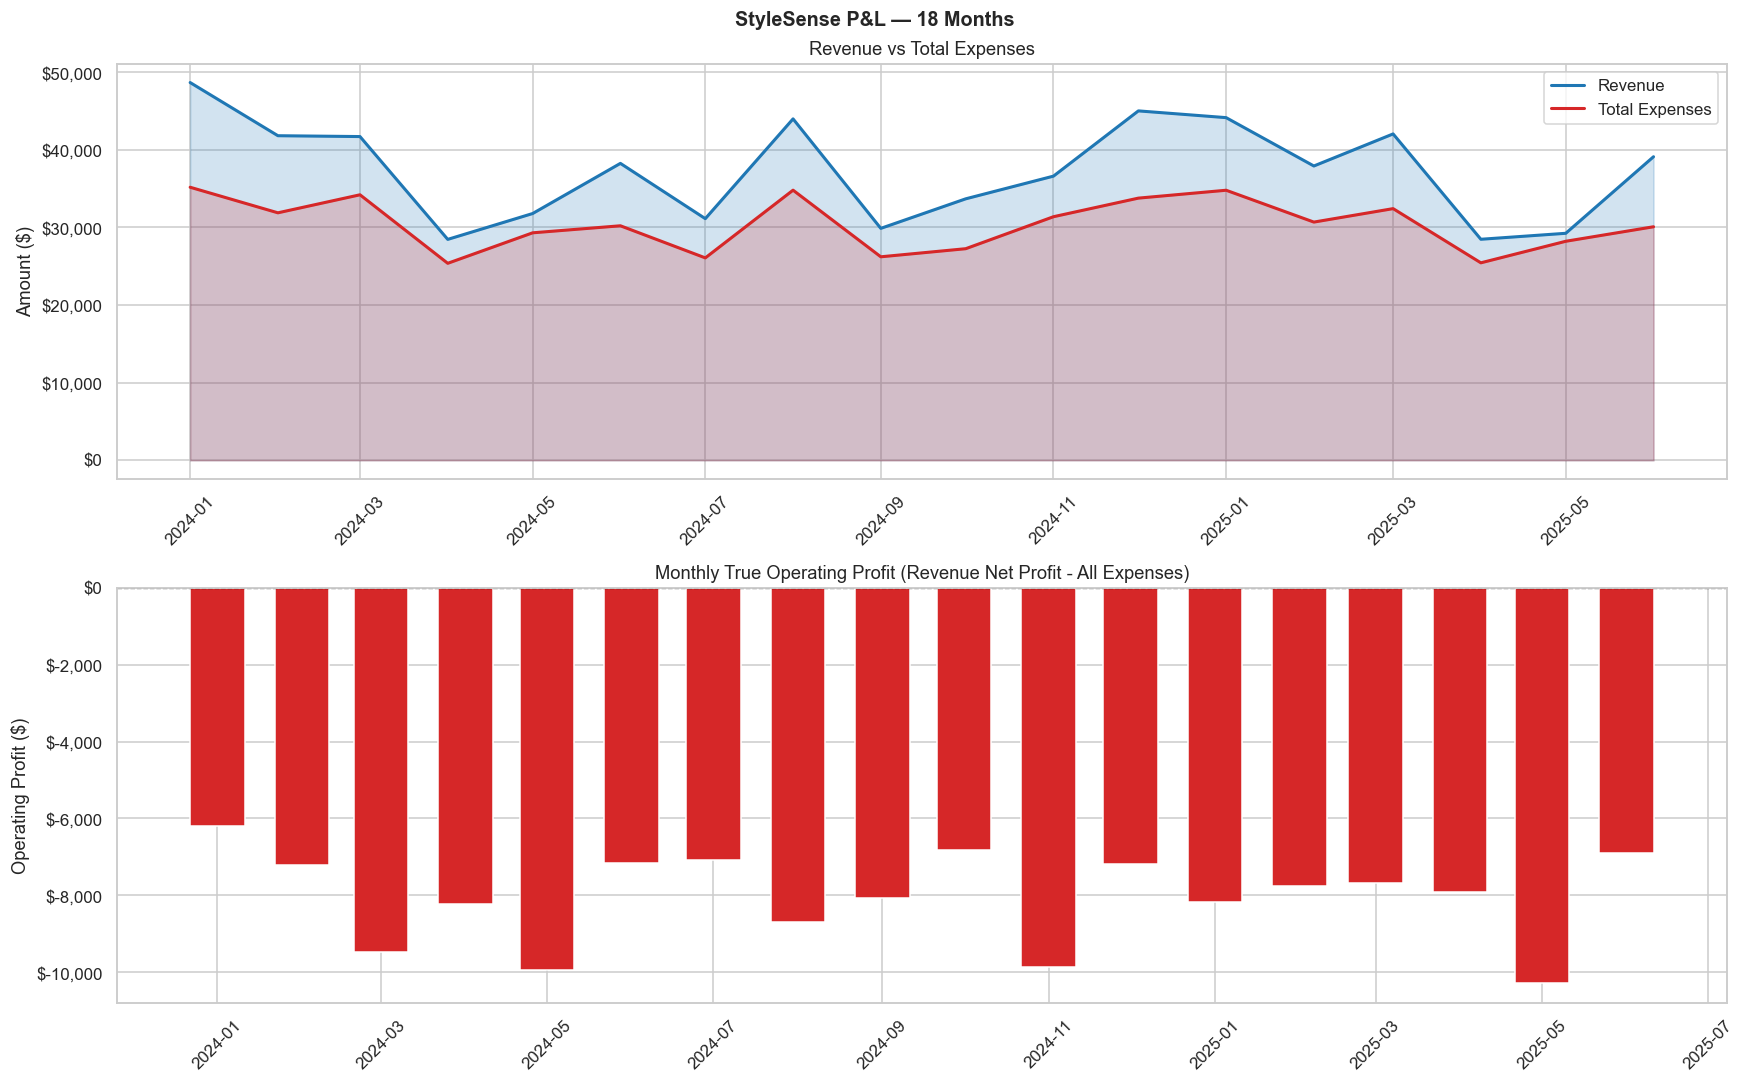

In [22]:
monthly_rev = sales.groupby('month').agg(
    revenue    = ('total_sale', 'sum'),
    net_profit = ('net_profit', 'sum')
).reset_index()

monthly_cost = expenses.groupby('month')['amount'].sum().reset_index()
monthly_cost.columns = ['month', 'expenses']

# Inner join: only months present in both datasets
pnl = monthly_rev.merge(monthly_cost, on='month', how='inner')

# True operating profit = net sales profit minus ALL operating expenses
pnl['true_profit'] = pnl['net_profit'] - pnl['expenses']
pnl['month_dt']    = pnl['month'].dt.to_timestamp()

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Panel 1: Revenue vs total expenses — the gap between the two lines is the gross surplus
axes[0].fill_between(pnl['month_dt'], pnl['revenue'],  alpha=0.2, color=BLUE)
axes[0].fill_between(pnl['month_dt'], pnl['expenses'], alpha=0.2, color=RED)
axes[0].plot(pnl['month_dt'], pnl['revenue'],  color=BLUE, linewidth=2, label='Revenue')
axes[0].plot(pnl['month_dt'], pnl['expenses'], color=RED,  linewidth=2, label='Total Expenses')
axes[0].set_title("Revenue vs Total Expenses")
axes[0].set_ylabel("Amount ($)")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
axes[0].legend()
axes[0].tick_params(axis='x', rotation=45)

# Panel 2: True operating profit — bar chart coloured by positive/negative
colors_bar = [GREEN if v >= 0 else RED for v in pnl['true_profit']]
axes[1].bar(pnl['month_dt'], pnl['true_profit'], color=colors_bar, width=20)
axes[1].axhline(0, color='black', linestyle='--', linewidth=0.8)
axes[1].set_title("Monthly True Operating Profit (Revenue Net Profit - All Expenses)")
axes[1].set_ylabel("Operating Profit ($)")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle("StyleSense P&L — 18 Months", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**What the charts show:**

**The gap between revenue and expenses is thin throughout the entire 18 months.**
Revenue ranges from **$29k to $49k** per month; expenses run from **$26k to $35k**.
The two lines track each other closely, leaving a narrow cushion.

**The operating profit panel tells the real story: every single month is in the red.**
All 18 bars are below zero. True operating profit ranges from approximately **$2,000
to $10,000** per month. The business is generating strong gross profit from sales,
but total operating expenses consistently exceed what is left after costs of goods
and returns.

**This does not mean the business is failing**, it means that payroll and COGS
together consume most of the gross margin. The loss is relatively contained
(under  **$10k/month  on $35k-$49k** revenue), but it is consistent.

**The most important implication:** any revenue growth analysis or margin improvement
work must be viewed in the context of this operating structure. Growing revenue without
controlling variable costs especially payroll, will not automatically move
the business into operating profit.

#### 2. RFM Segments: Actual Purchase Behaviour in Sales

The RFM segments were built from the customer table. Here we join them onto
the sales transactions to see how Champions, Loyals, At Risk, and other segments
actually behave in terms of revenue contribution, order value, and returns.

Transactions matched to a customer segment: 9,889 of 9,989

Sales behaviour by RFM segment:
RFM_segment  transactions  total_revenue  avg_order_value  avg_margin  avg_discount  return_rate
   Champion           759       59620.90        78.551910        60.8           5.3          5.7
      Loyal          3494      255075.73        73.003930        61.5           5.3          4.6
  Potential          2669      178575.83        66.907392        61.5           5.4          4.5
    At Risk          1889      112062.85        59.323902        60.5           5.5          6.0
       Lost          1078       59960.23        55.621735        62.2           4.8          4.0


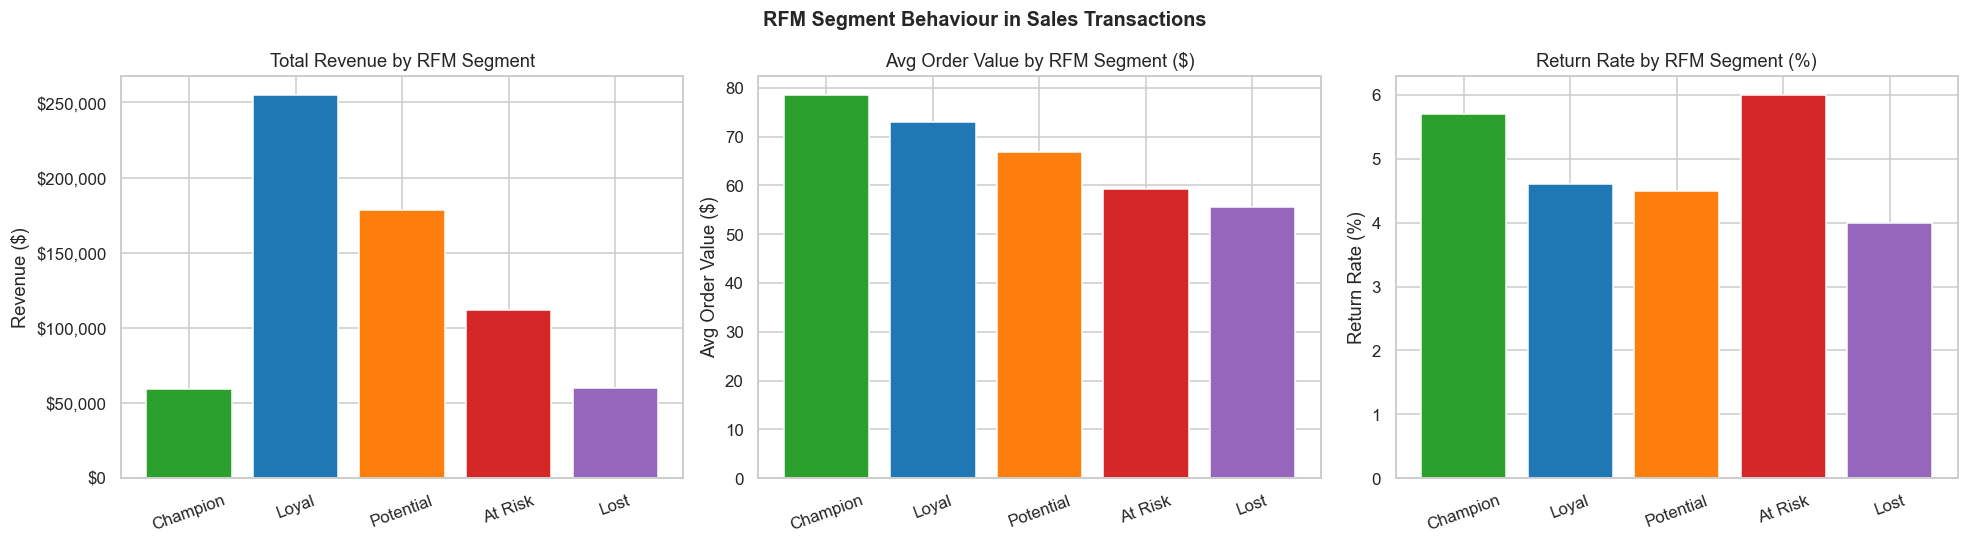

In [23]:
# Join RFM segment labels onto sales transactions by customer_id
sales_rfm = sales.merge(
    customers[['customer_id', 'RFM_segment', 'segment', 'age_group']],
    on='customer_id', how='inner'
)

print(f"Transactions matched to a customer segment: {len(sales_rfm):,} of {len(sales):,}")
print()

rfm_sales = sales_rfm.groupby('RFM_segment').agg(
    transactions    = ('sale_id', 'count'),
    total_revenue   = ('total_sale', 'sum'),
    avg_order_value = ('total_sale', 'mean'),
    avg_margin      = ('profit_margin_pct', 'mean'),
    avg_discount    = ('discount_pct', 'mean'),
    return_rate     = ('is_returned', 'mean')
).reset_index()
rfm_sales['return_rate']  = (rfm_sales['return_rate'] * 100).round(1)
rfm_sales['avg_margin']   = rfm_sales['avg_margin'].round(1)
rfm_sales['avg_discount'] = rfm_sales['avg_discount'].round(1)

seg_order = ['Champion', 'Loyal', 'Potential', 'At Risk', 'Lost']
rfm_sales['RFM_segment'] = pd.Categorical(rfm_sales['RFM_segment'], categories=seg_order, ordered=True)
rfm_sales = rfm_sales.sort_values('RFM_segment')

print("Sales behaviour by RFM segment:")
print(rfm_sales.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = [GREEN, BLUE, ORANGE, RED, PURPLE]

axes[0].bar(rfm_sales['RFM_segment'], rfm_sales['total_revenue'], color=colors)
axes[0].set_title("Total Revenue by RFM Segment")
axes[0].set_ylabel("Revenue ($)")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
axes[0].tick_params(axis='x', rotation=20)

axes[1].bar(rfm_sales['RFM_segment'], rfm_sales['avg_order_value'], color=colors)
axes[1].set_title("Avg Order Value by RFM Segment ($)")
axes[1].set_ylabel("Avg Order Value ($)")
axes[1].tick_params(axis='x', rotation=20)

axes[2].bar(rfm_sales['RFM_segment'], rfm_sales['return_rate'], color=colors)
axes[2].set_title("Return Rate by RFM Segment (%)")
axes[2].set_ylabel("Return Rate (%)")
axes[2].tick_params(axis='x', rotation=20)

plt.suptitle("RFM Segment Behaviour in Sales Transactions", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

#### 3. Seasonal Product Sales vs Inventory Stock

Do stock levels rise to meet seasonal demand — or do they fall at the wrong time?
This chart overlays monthly revenue (bars) with average stock level (red line)
for winter and summer products separately.

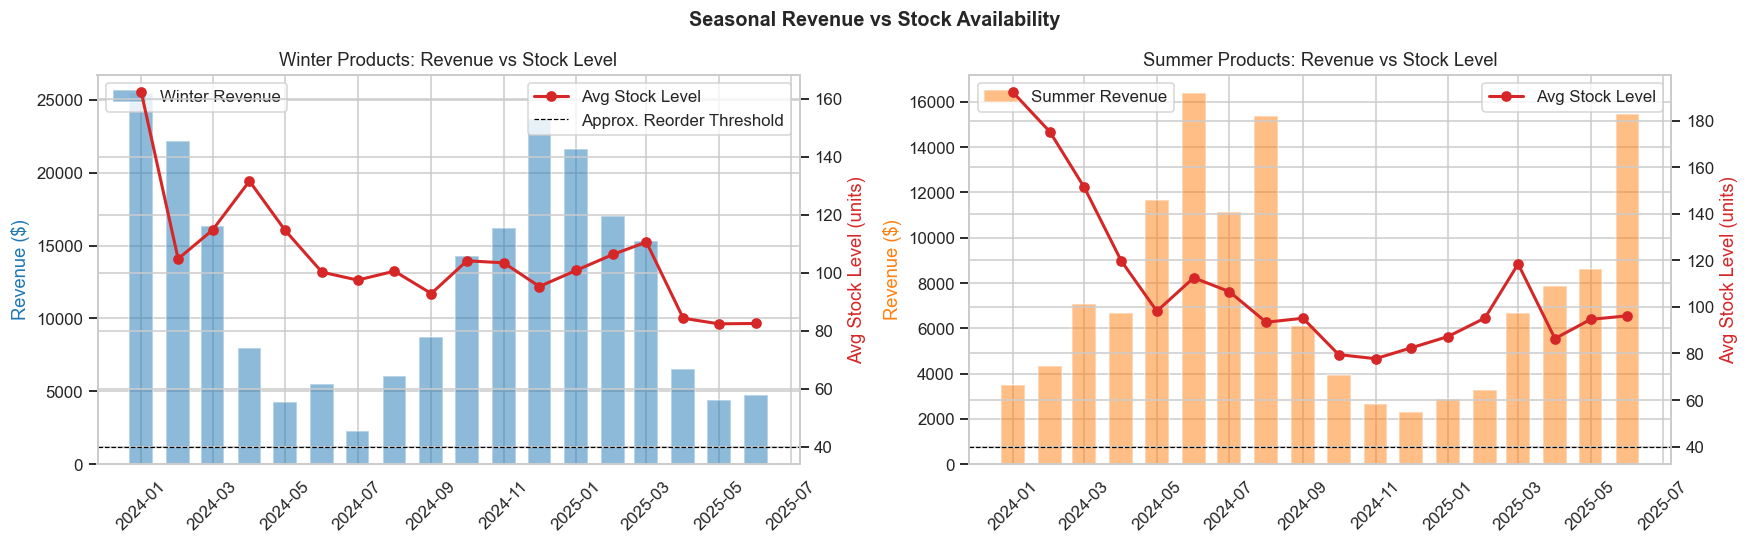

In [24]:
seasonal_sales = sales[sales['season'].isin(['Winter', 'Summer'])].copy()
seasonal_monthly = seasonal_sales.groupby(['month', 'season'])['total_sale'].sum().reset_index()
seasonal_monthly['month_dt'] = seasonal_monthly['month'].dt.to_timestamp()

winter_sales = seasonal_monthly[seasonal_monthly['season'] == 'Winter']
summer_sales = seasonal_monthly[seasonal_monthly['season'] == 'Summer']

# Join season tag from products onto inventory records
inv_seasonal = inventory.merge(products[['product_id', 'season']], on='product_id', how='left')
inv_seasonal = inv_seasonal[inv_seasonal['season'].isin(['Winter', 'Summer'])]
inv_monthly  = inv_seasonal.groupby(['month', 'season'])['stock_level'].mean().reset_index()
inv_monthly['month_dt'] = inv_monthly['month'].dt.to_timestamp()

winter_stock = inv_monthly[inv_monthly['season'] == 'Winter']
summer_stock = inv_monthly[inv_monthly['season'] == 'Summer']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# twinx() creates a second y-axis so revenue ($) and stock (units) share one chart
ax_w2 = axes[0].twinx()
axes[0].bar(winter_sales['month_dt'], winter_sales['total_sale'],
            width=20, alpha=0.5, color=BLUE, label='Winter Revenue')
ax_w2.plot(winter_stock['month_dt'], winter_stock['stock_level'],
           color=RED, marker='o', linewidth=2, label='Avg Stock Level')
ax_w2.axhline(40, color='black', linestyle='--', linewidth=0.8, label='Approx. Reorder Threshold')
axes[0].set_title("Winter Products: Revenue vs Stock Level")
axes[0].set_ylabel("Revenue ($)", color=BLUE)
ax_w2.set_ylabel("Avg Stock Level (units)", color=RED)
axes[0].legend(loc='upper left')
ax_w2.legend(loc='upper right')
axes[0].tick_params(axis='x', rotation=45)

ax_s2 = axes[1].twinx()
axes[1].bar(summer_sales['month_dt'], summer_sales['total_sale'],
            width=20, alpha=0.5, color=ORANGE, label='Summer Revenue')
ax_s2.plot(summer_stock['month_dt'], summer_stock['stock_level'],
           color=RED, marker='o', linewidth=2, label='Avg Stock Level')
ax_s2.axhline(40, color='black', linestyle='--', linewidth=0.8)
axes[1].set_title("Summer Products: Revenue vs Stock Level")
axes[1].set_ylabel("Revenue ($)", color=ORANGE)
ax_s2.set_ylabel("Avg Stock Level (units)", color=RED)
axes[1].legend(loc='upper left')
ax_s2.legend(loc='upper right')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle("Seasonal Revenue vs Stock Availability", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**What the charts show:**

Winter products (left chart): Revenue peaks in Jan 2024 ($25k) and again in Nov–Dec 2024 ($23k). Stock starts high (160 units) and steadily declines to 80–90 units by mid-2025, never below the reorder threshold (40 units). Supply chain handles winter seasonality well.

Summer products (right chart): Revenue peaks in Jan 2024 ($16k) and May 2024 ($16k), suggesting year-round demand or early purchases. Stock starts high (175 units) and declines gradually but stays above the reorder threshold.

Conclusion: Seasonal stock levels are safe. Any stockouts (e.g., Men's Swim Shorts in November) are product-specific, not category-wide.